1. Mount Drive and install packages

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install shap imbalanced-learn openpyxl

Mounted at /content/drive


2. Imports and settings

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import skew, boxcox, randint
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style="whitegrid")

BASE_PATH = "/content/drive/MyDrive"
DATA_PATH = f"{BASE_PATH}/HBV_Dataset.xlsx"

OUT_DIR = Path("/content/drive/MyDrive/HBV_RF_Final_Outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = "Status"

print("File exists:", os.path.exists(DATA_PATH))

File exists: True


3. Helper Functions

In [3]:
NUM_COLS = ['Age', 'HBVDNA', 'ALTLevel', 'ASTLevel', 'Bilirubin']
CAT_COLS = ['Gender', 'Jaundice', 'DarkUrine', 'AbdominalPain', 'VomitingFrequency', 'LossofAppetite']

ENCODING_MAPS = {
    "Gender": {"F": 0, "M": 1},
    "Jaundice": {"no": 0, "yes": 1},
    "DarkUrine": {"no": 0, "yes": 1},
    "AbdominalPain": {"none": 0, "mild": 1, "moderate": 2, "severe": 3},
    "VomitingFrequency": {"none": 0, "rare": 1, "moderate": 2, "frequent": 3},
    "LossofAppetite": {"no": 0, "yes": 1},
    "Status": {"Negative": 0, "Positive": 1}
}

def parse_hbvdna(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        s = x.strip()
        if s.lower() == "not detected":
            return 0.0
        try:
            return float(s)
        except:
            return np.nan
    return float(x)

def eval_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob)
    }

def preprocess_fit_transform(train_df, valid_df=None, test_df=None):
    train_df = train_df.copy()
    valid_df = None if valid_df is None else valid_df.copy()
    test_df  = None if test_df is None else test_df.copy()

    # Numeric imputation from train only
    medians = {}
    for col in NUM_COLS:
        medians[col] = train_df[col].median()
        train_df[col] = train_df[col].fillna(medians[col])
        if valid_df is not None:
            valid_df[col] = valid_df[col].fillna(medians[col])
        if test_df is not None:
            test_df[col] = test_df[col].fillna(medians[col])

    # Categorical imputation from train only
    modes = {}
    for col in CAT_COLS:
        modes[col] = train_df[col].mode()[0]
        train_df[col] = train_df[col].fillna(modes[col])
        if valid_df is not None:
            valid_df[col] = valid_df[col].fillna(modes[col])
        if test_df is not None:
            test_df[col] = test_df[col].fillna(modes[col])

    # Encoding
    for col, mp in ENCODING_MAPS.items():
        train_df[col] = train_df[col].map(mp)
        if valid_df is not None:
            valid_df[col] = valid_df[col].map(mp)
        if test_df is not None:
            test_df[col] = test_df[col].map(mp)

    # Box-Cox on skewed numeric columns based on train only
    boxcox_cols = []
    lambdas = {}
    for col in NUM_COLS:
        train_sk = skew(train_df[col].astype(float))
        if abs(train_sk) > 1:
            boxcox_cols.append(col)

            train_vals = train_df[col].astype(float).values + 1.0
            transformed, lam = boxcox(train_vals)
            train_df[col] = transformed
            lambdas[col] = lam

            if valid_df is not None:
                vals = valid_df[col].astype(float).values + 1.0
                valid_df[col] = np.log(vals) if abs(lam) < 1e-8 else (np.power(vals, lam) - 1) / lam

            if test_df is not None:
                vals = test_df[col].astype(float).values + 1.0
                test_df[col] = np.log(vals) if abs(lam) < 1e-8 else (np.power(vals, lam) - 1) / lam

    # Standardization using train only
    scaler = StandardScaler()
    train_df[NUM_COLS] = scaler.fit_transform(train_df[NUM_COLS])

    if valid_df is not None:
        valid_df[NUM_COLS] = scaler.transform(valid_df[NUM_COLS])

    if test_df is not None:
        test_df[NUM_COLS] = scaler.transform(test_df[NUM_COLS])

    return train_df, valid_df, test_df, boxcox_cols, lambdas

def save_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=400, bbox_inches="tight")
    plt.show()
    plt.close()

def optimize_threshold(y_true, y_prob, thresholds=np.arange(0.30, 0.71, 0.01)):
    best_threshold = 0.50
    best_score = -1
    best_row = None

    rows = []
    for th in thresholds:
        pred = (y_prob >= th).astype(int)
        acc = accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        score = acc + f1
        rows.append([th, acc, prec, rec, f1, score])

        if score > best_score:
            best_score = score
            best_threshold = th
            best_row = [th, acc, prec, rec, f1, score]

    th_df = pd.DataFrame(rows, columns=["Threshold", "Accuracy", "Precision", "Recall", "F1", "Objective"])
    return best_threshold, pd.DataFrame([best_row], columns=th_df.columns), th_df

def get_shap_matrix(shap_values):
    vals = shap_values.values
    if vals.ndim == 3:
        return vals[:, :, 1], shap_values.base_values[:, 1]
    return vals, shap_values.base_values

4. Load and inspect dataset

In [4]:
df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()
df["HBVDNA"] = df["HBVDNA"].apply(parse_hbvdna)

print("Shape:", df.shape)
display(df.head())

print("\nClass counts:")
print(df[TARGET_COL].value_counts())

print("\nMissing values:")
print(df.isna().sum())

# Save quick audit
audit = {
    "shape": list(df.shape),
    "class_counts": df[TARGET_COL].value_counts(dropna=False).to_dict(),
    "missing_values": df.isna().sum().to_dict()
}
with open(OUT_DIR / "dataset_audit.json", "w") as f:
    json.dump(audit, f, indent=2)

Shape: (216, 13)


,Age,Gender,Jaundice,DarkUrine,AbdominalPain,VomitingFrequency,LossofAppetite,HBVDNA,ALTLevel,ASTLevel,Bilirubin,Albumin,Status
0,66,F,yes,yes,mild,moderate,yes,2.990000e+11,77.4,104.0,5.90,NaN,Positive
1,69,M,no,no,mild,rare,yes,2.740095e+06,116.0,90.0,0.79,3.80,Positive
2,20,F,no,no,mild,rare,yes,5.483606e+07,68.0,40.0,0.72,3.80,Positive
3,29,M,no,no,mild,rare,yes,3.350000e+07,49.2,45.4,0.45,NaN,Positive
4,30,M,no,no,none,none,no,5.186982e+07,34.4,28.5,0.34,3.68,Positive



Class counts:
Status
Positive    116
Negative    100
Name: count, dtype: int64

Missing values:
Age                    0
Gender                 0
Jaundice              20
DarkUrine             20
AbdominalPain         17
VomitingFrequency     17
LossofAppetite        17
HBVDNA                 2
ALTLevel              17
ASTLevel              18
Bilirubin             23
Albumin              116
Status                 0
dtype: int64


5. EDA and preprocessing charts

EDA numeric columns used: ['Age', 'HBVDNA', 'ALTLevel', 'ASTLevel', 'Bilirubin']
Box-Cox applied: {'Age': None, 'HBVDNA': {'lambda': np.float64(-0.05911636767029004), 'shift': 1.0}, 'ALTLevel': {'lambda': np.float64(-0.4255772396108038), 'shift': 1.0}, 'ASTLevel': {'lambda': np.float64(-0.48416592648481876), 'shift': 1.0}, 'Bilirubin': {'lambda': np.float64(-1.528020155358007), 'shift': 1.0}}


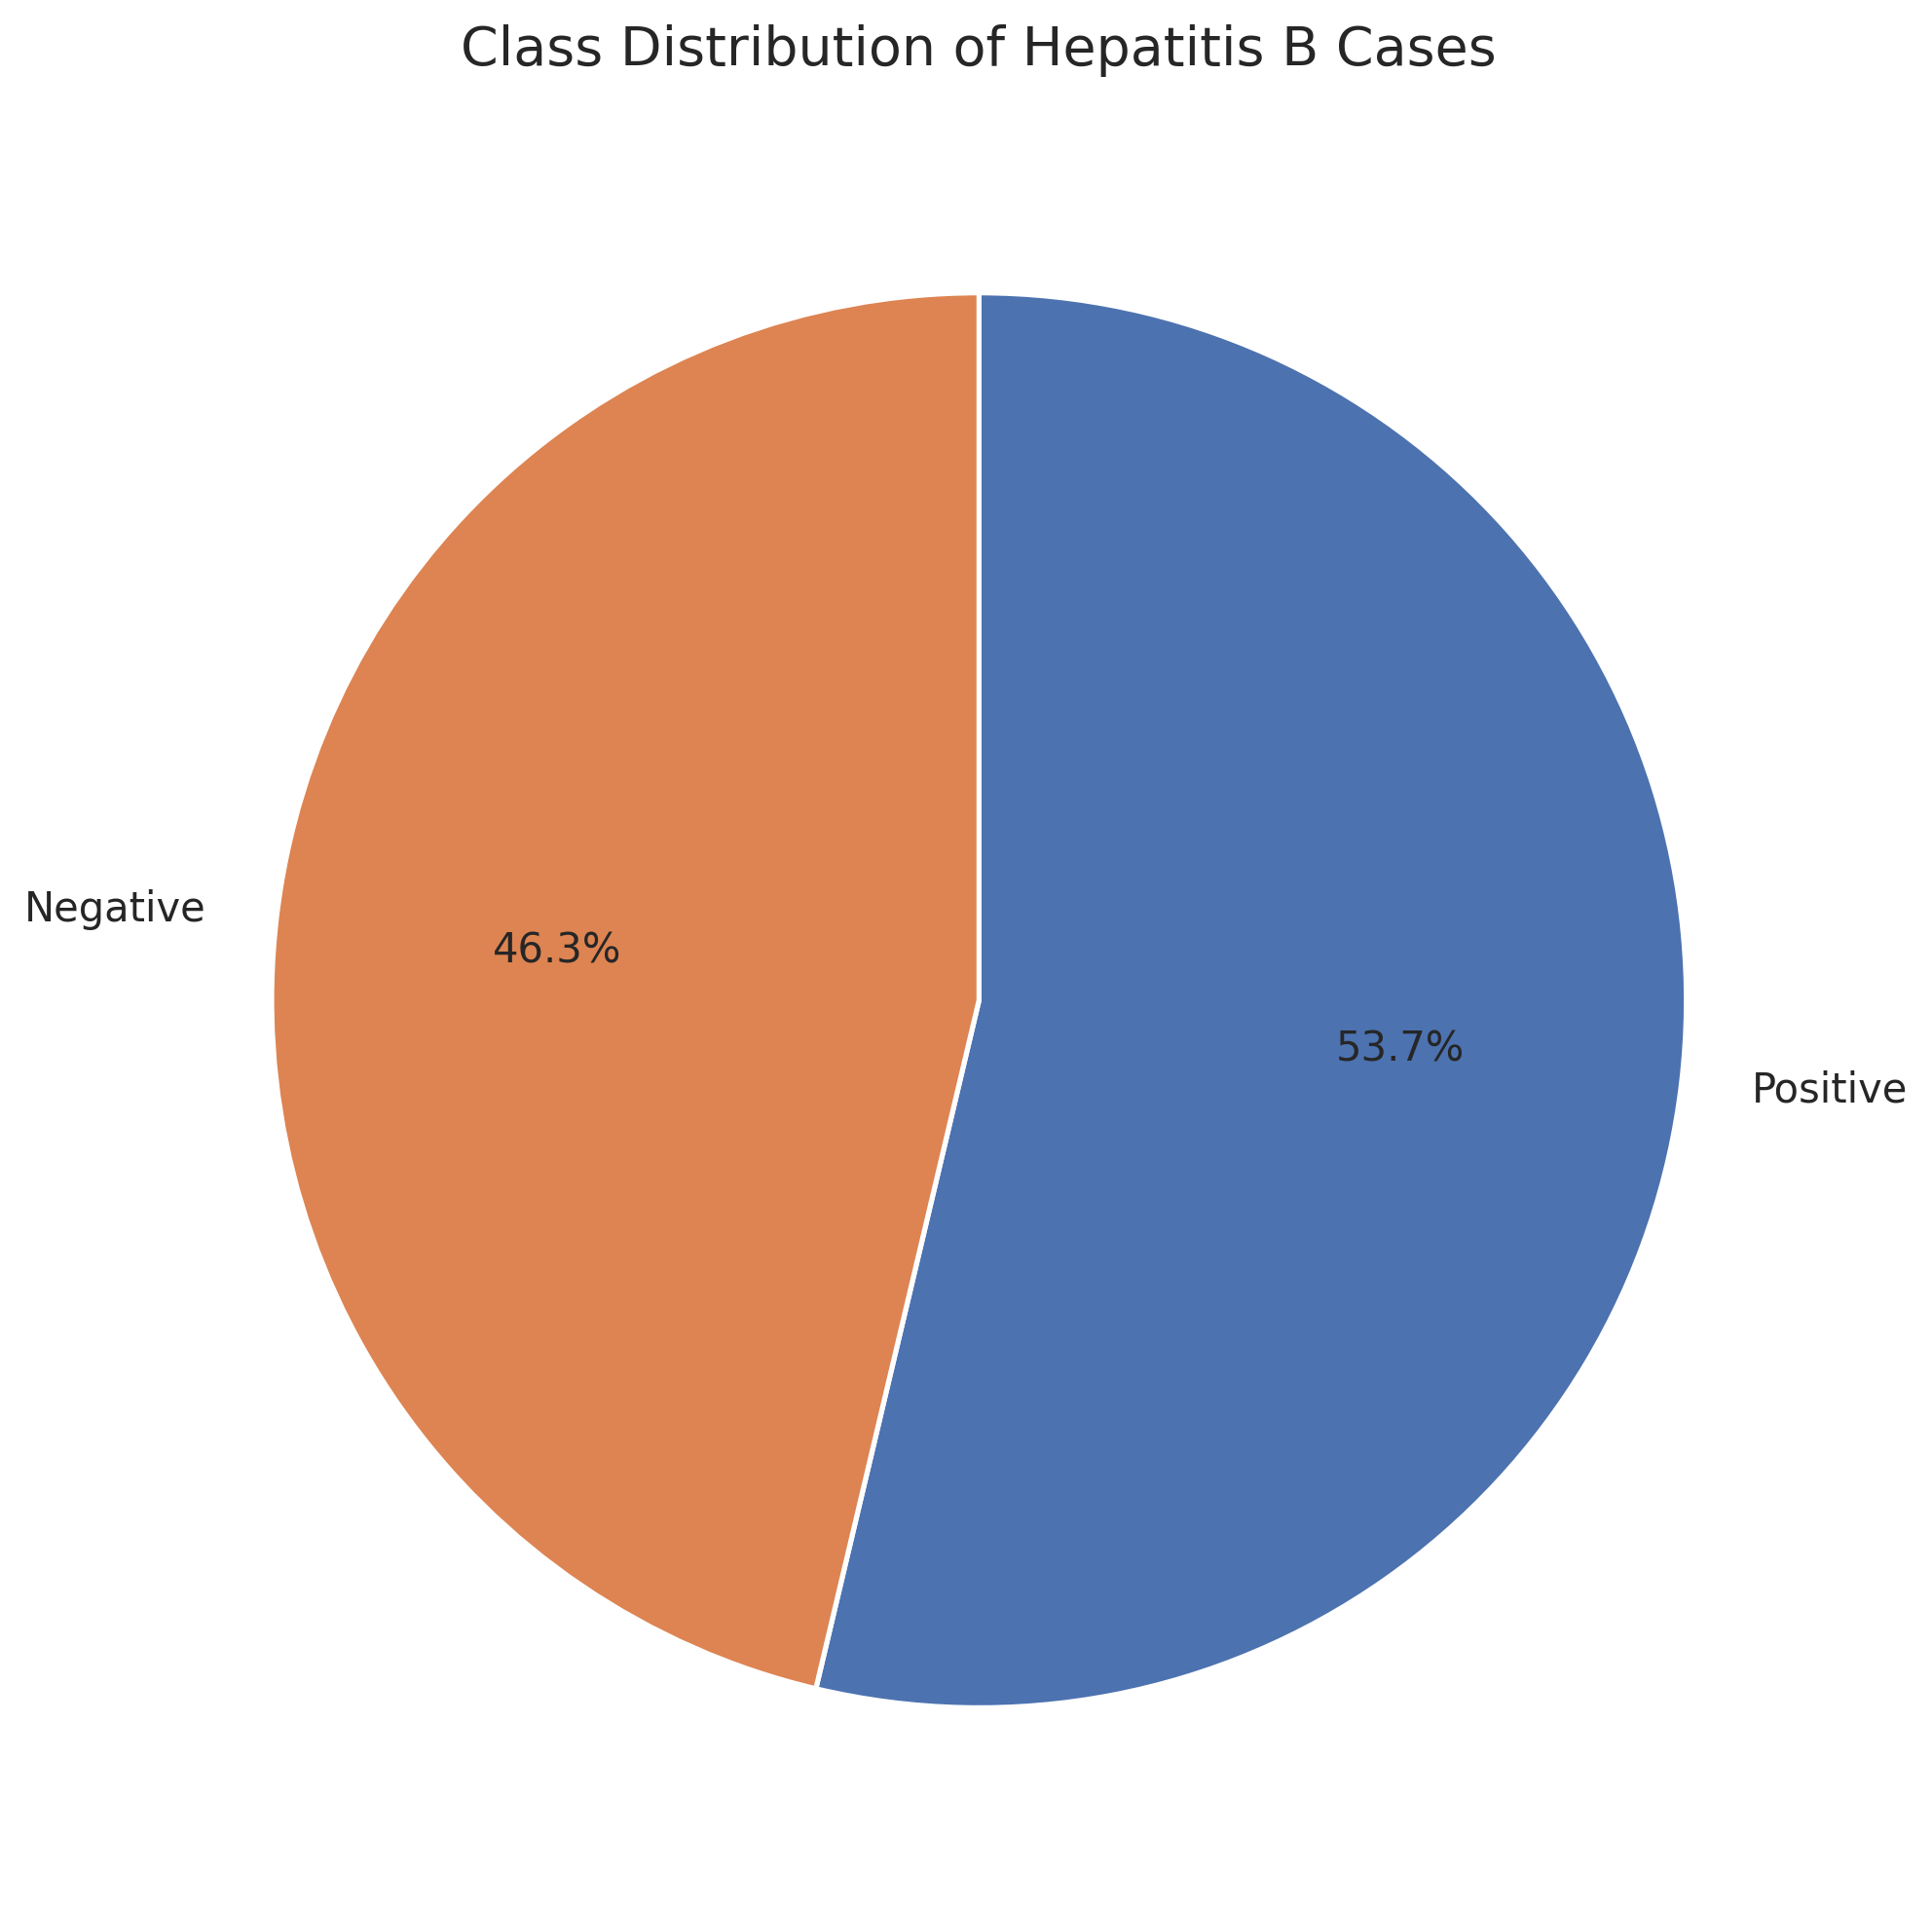

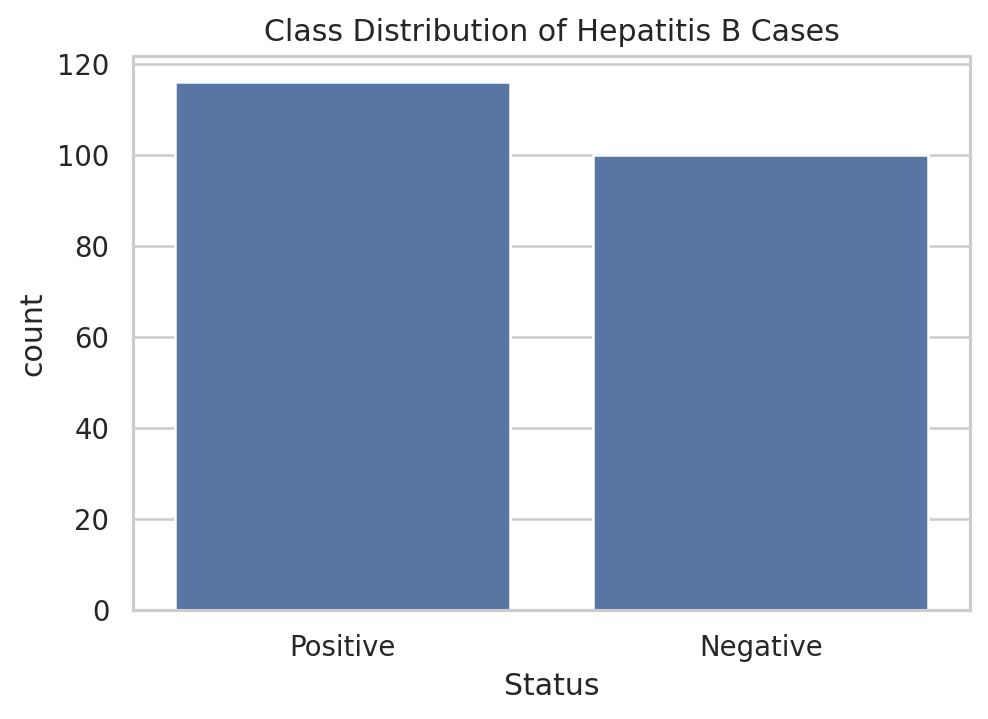

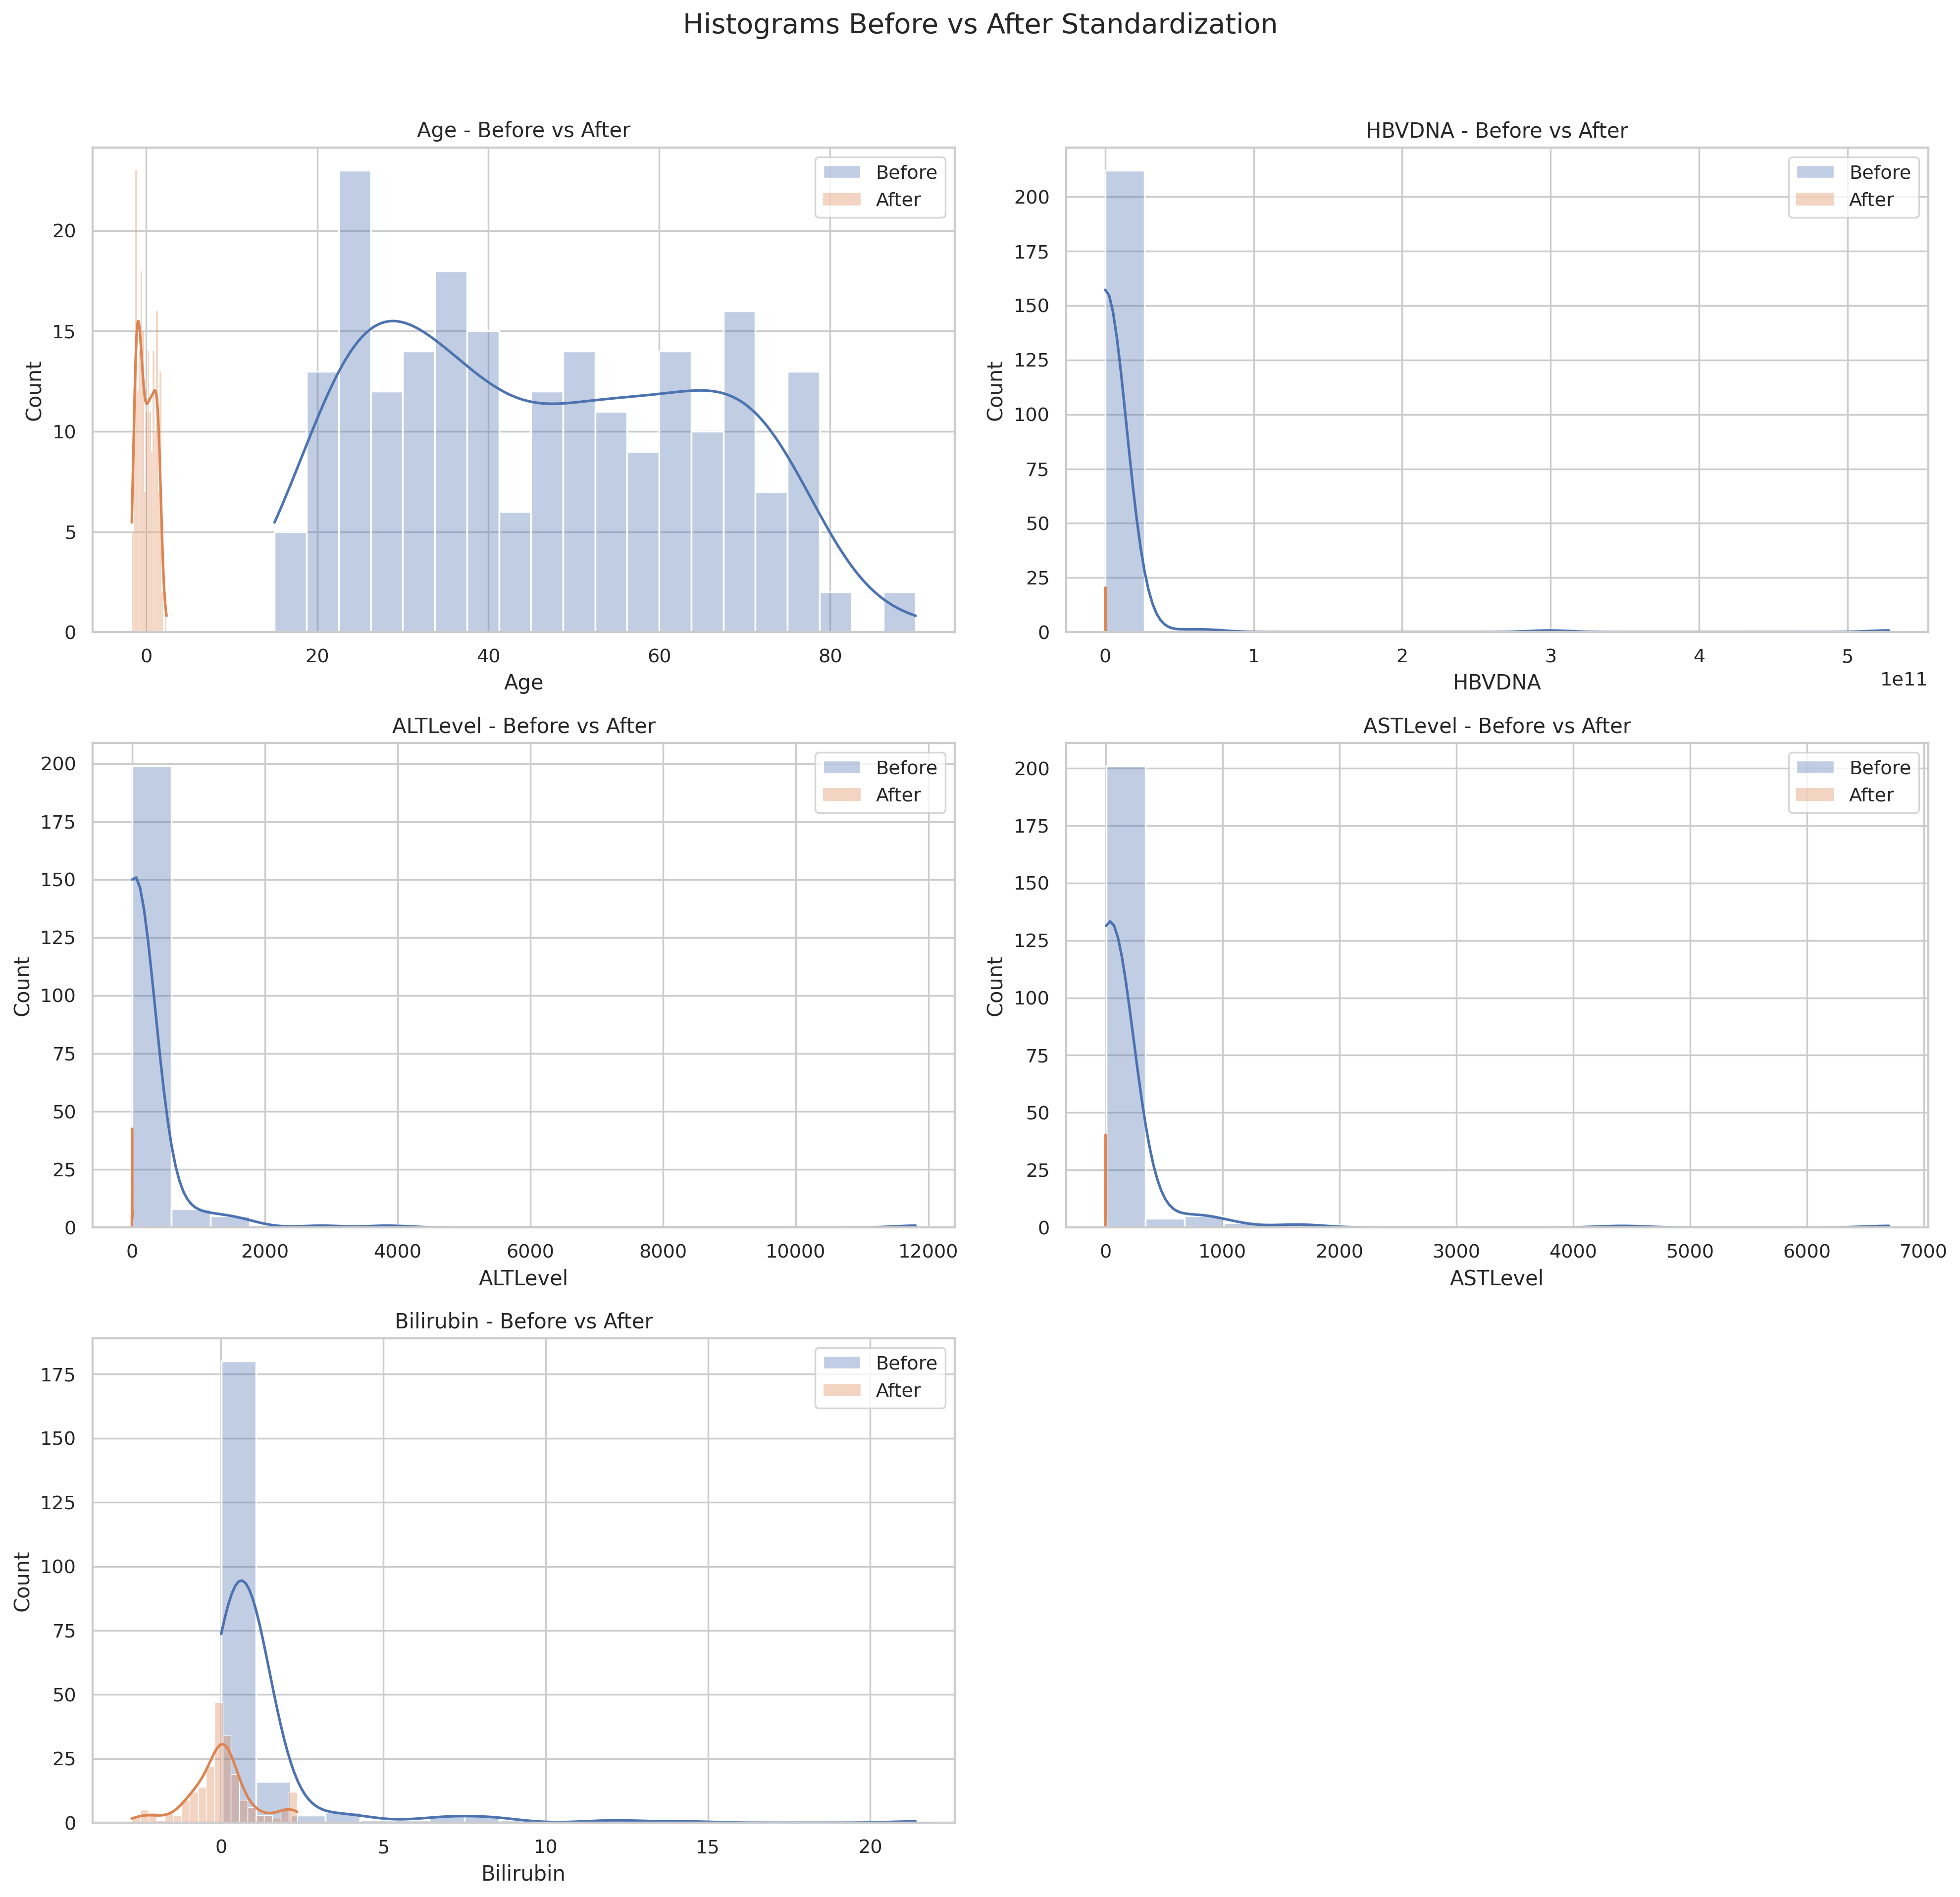

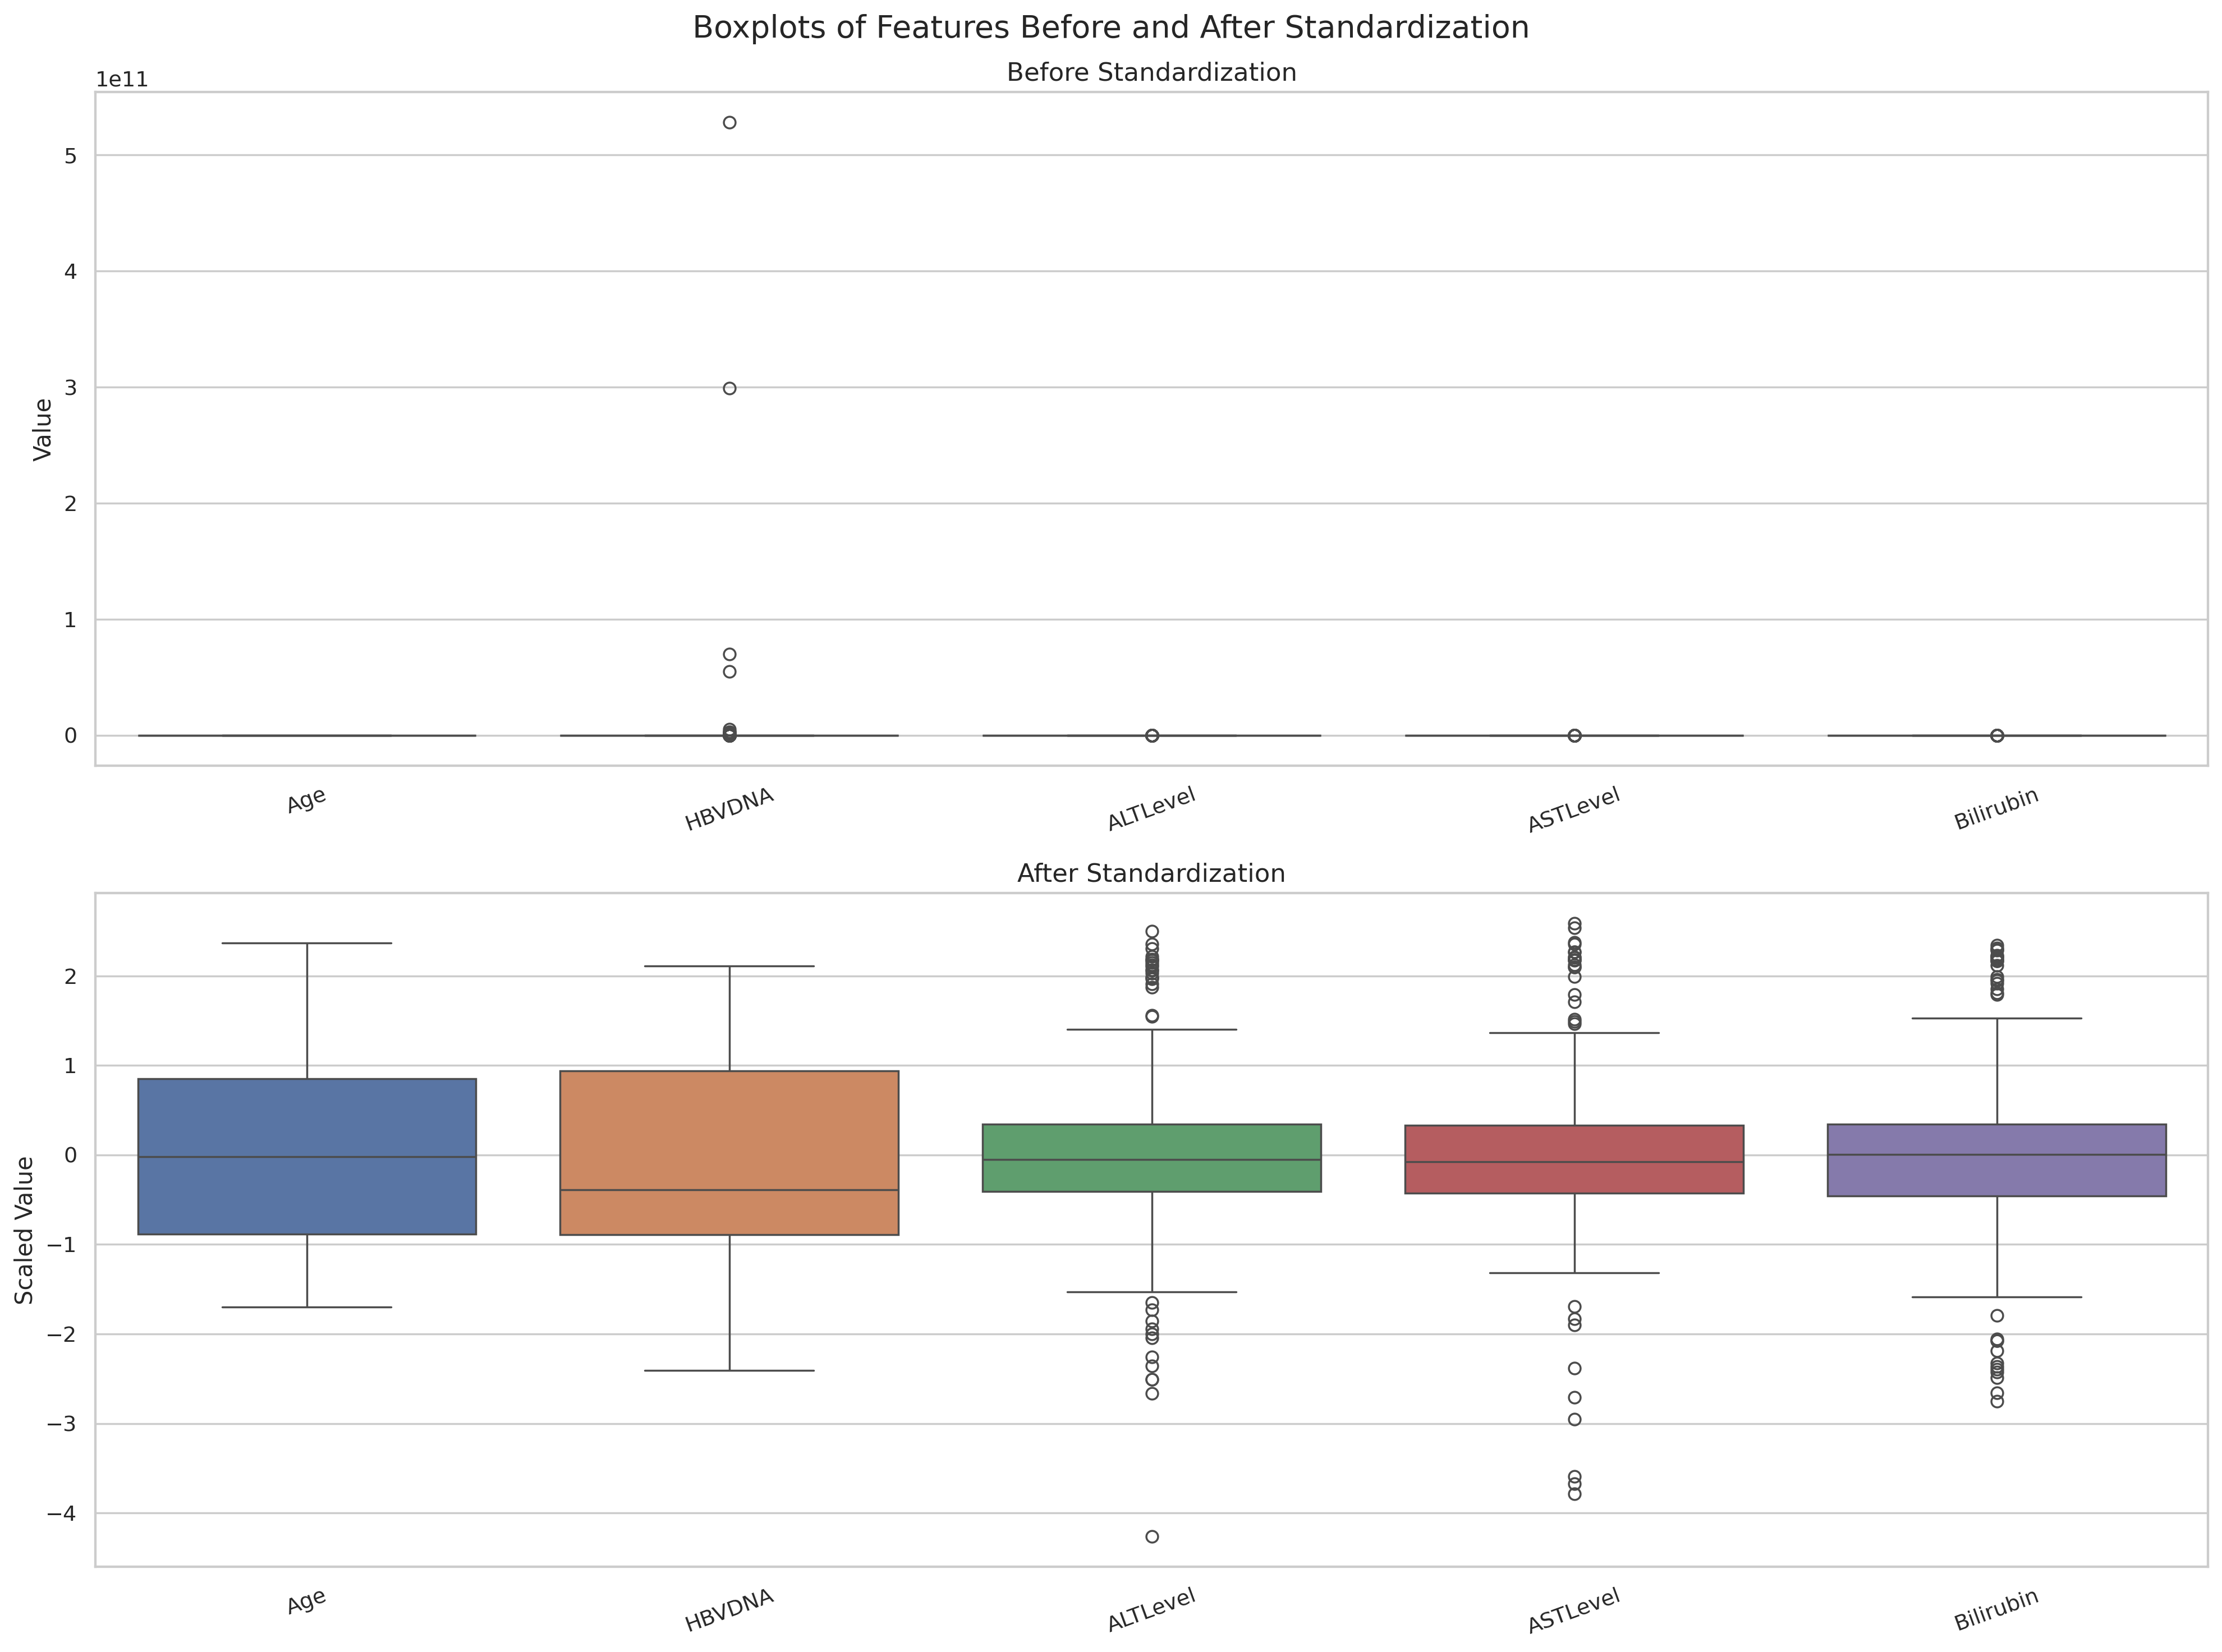

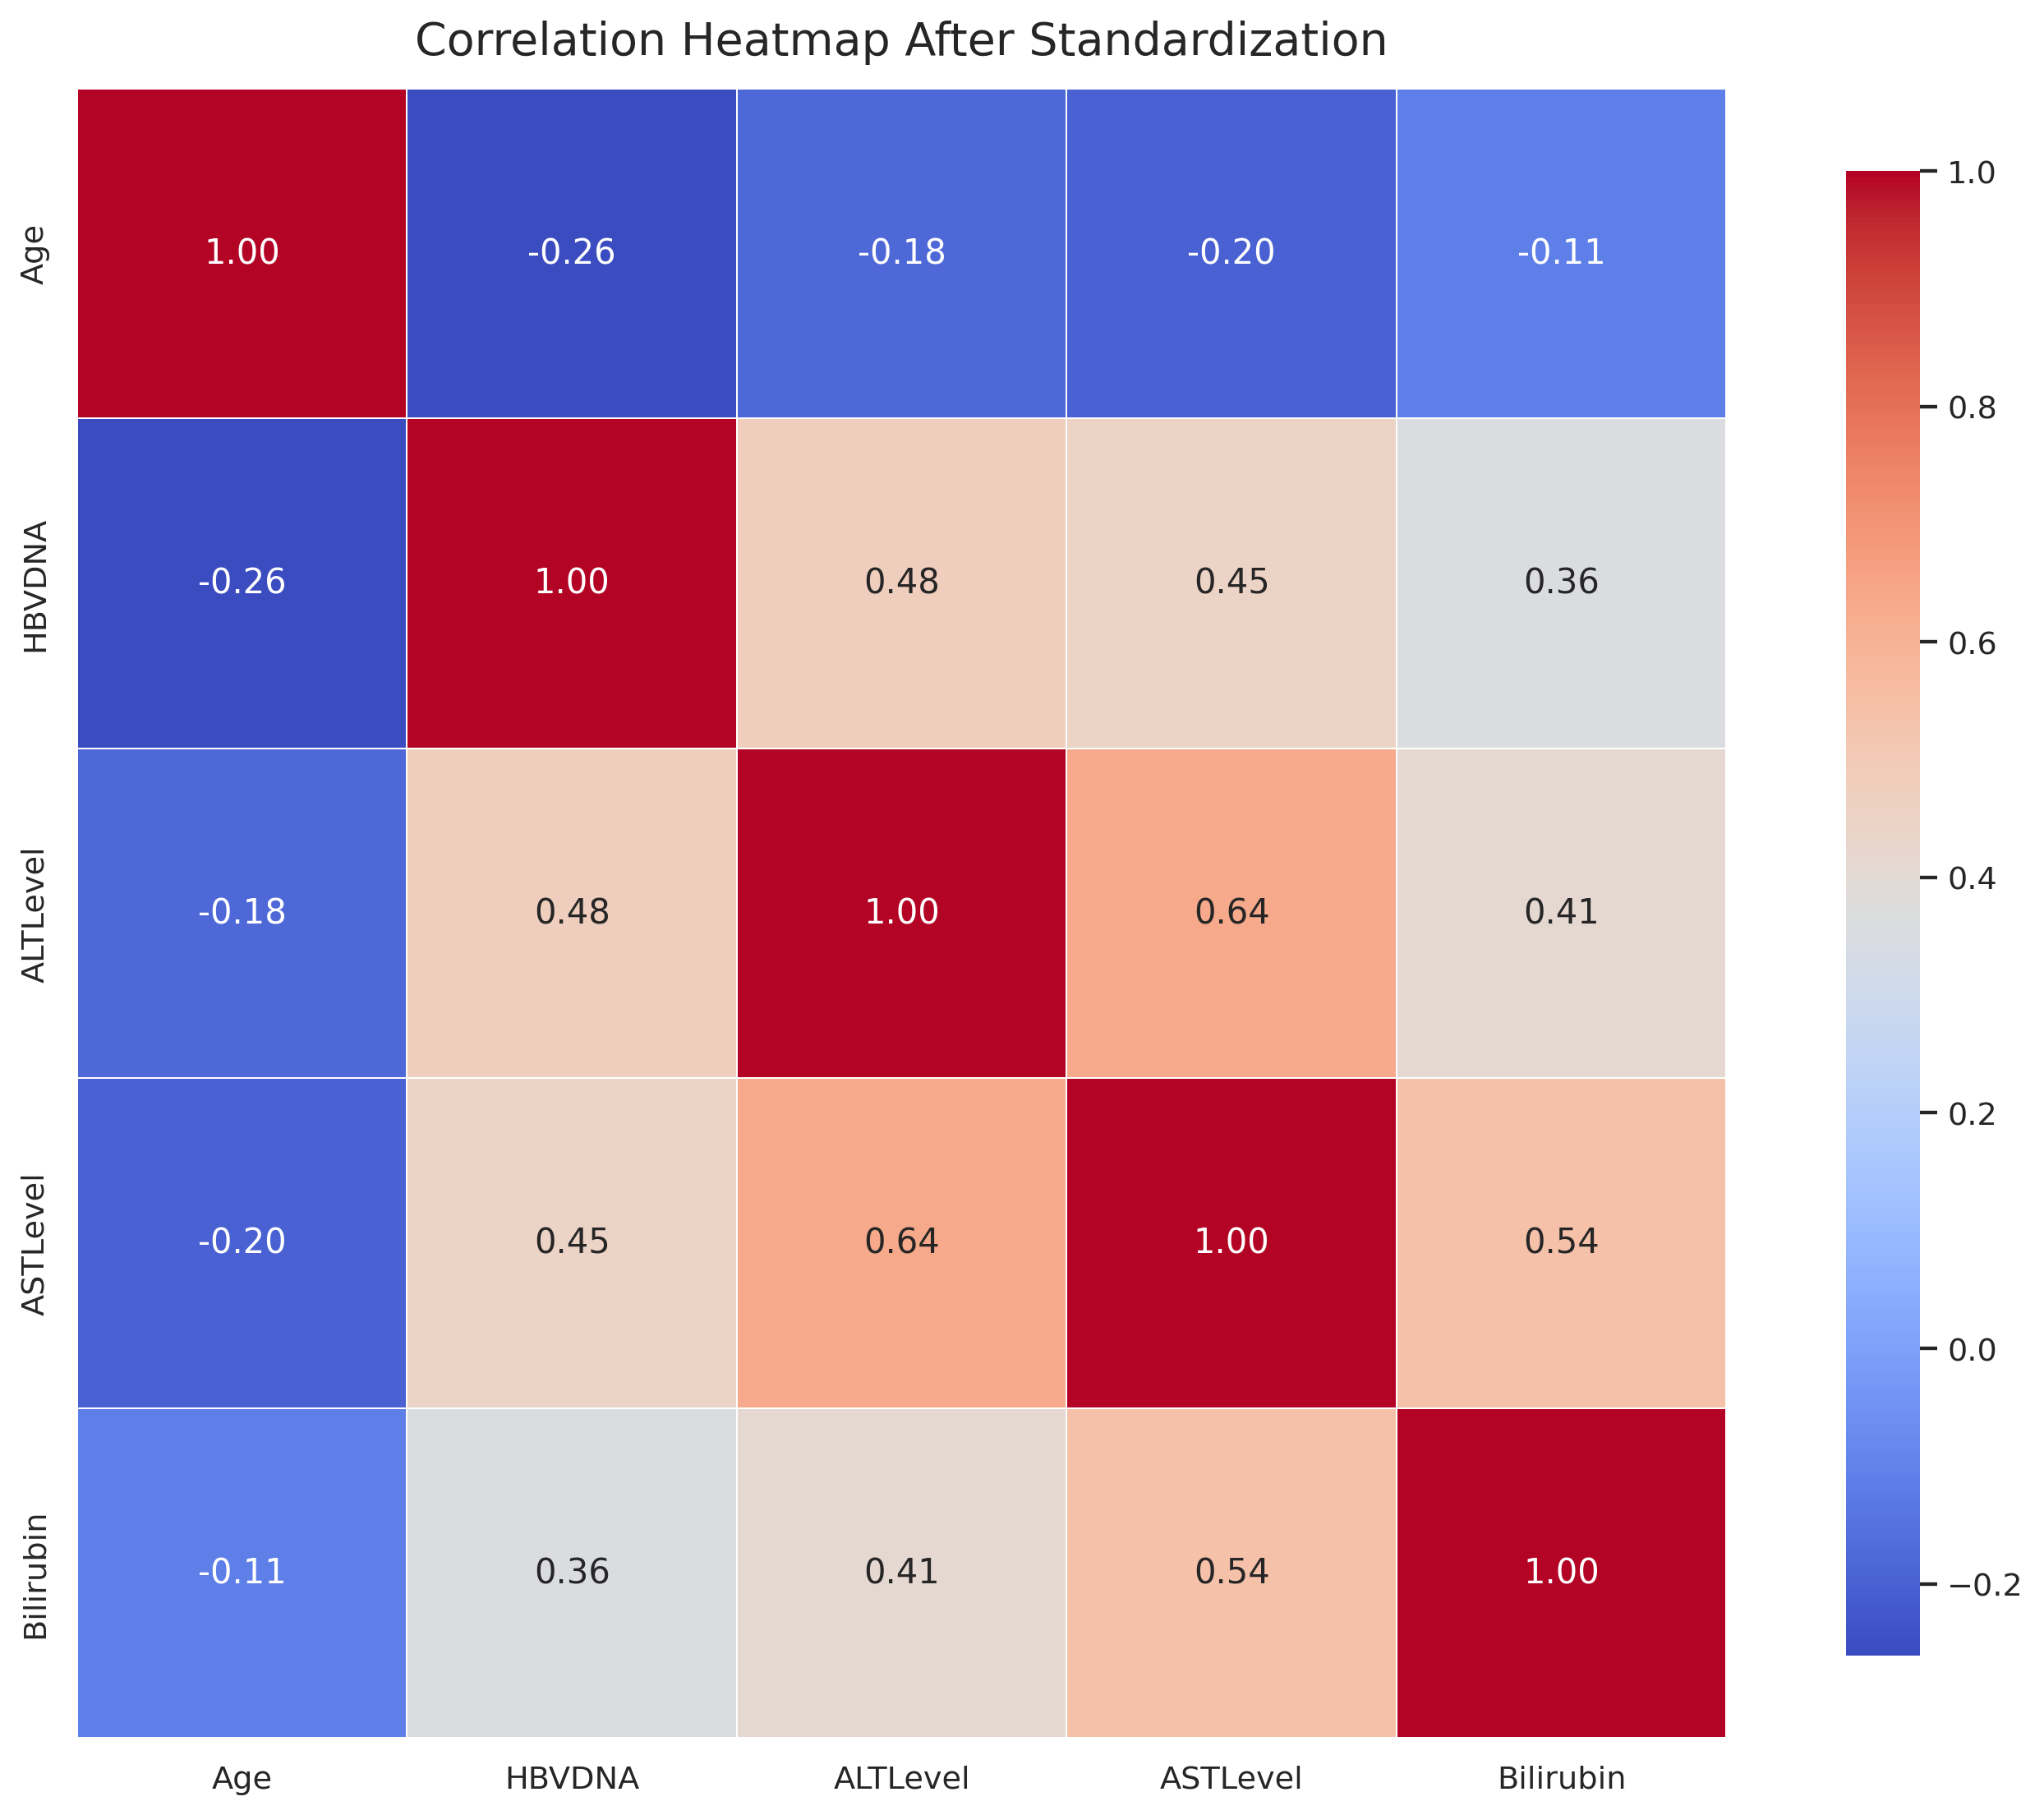

In [5]:
# 5. EDA + High Quality figures
import math
eda_df = df.copy()

if "Albumin" in eda_df.columns:
    eda_df = eda_df.drop(columns=["Albumin"])

EDA_NUM_COLS = [col for col in NUM_COLS if col in eda_df.columns]
EDA_CAT_COLS = [col for col in CAT_COLS if col in eda_df.columns]

for col in EDA_NUM_COLS:
    eda_df[col] = eda_df[col].fillna(eda_df[col].median())

for col in EDA_CAT_COLS:
    eda_df[col] = eda_df[col].fillna(eda_df[col].mode()[0])

for col, mp in ENCODING_MAPS.items():
    if col in eda_df.columns:
        eda_df[col] = eda_df[col].map(mp)

eda_boxcox_df = eda_df.copy()
boxcox_info = {}

for col in EDA_NUM_COLS:
    vals = eda_boxcox_df[col].astype(float)
    sk = skew(vals.dropna())

    if abs(sk) > 1:
        min_val = vals.min()
        shift_val = 1.0 if min_val > 0 else abs(min_val) + 1.0
        transformed, lam = boxcox(vals.values + shift_val)
        eda_boxcox_df[col] = transformed
        boxcox_info[col] = {"lambda": lam, "shift": shift_val}
    else:
        boxcox_info[col] = None

# Standardization
eda_scaled_df = eda_boxcox_df.copy()
scaler_eda = StandardScaler()
eda_scaled_df[EDA_NUM_COLS] = scaler_eda.fit_transform(eda_scaled_df[EDA_NUM_COLS])

print("EDA numeric columns used:", EDA_NUM_COLS)
print("Box-Cox applied:", boxcox_info)


plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 300
sns.set_theme(style="whitegrid")

counts = df[TARGET_COL].value_counts()

pie_labels = []
for idx in counts.index:
    if idx == 0 or idx == "Negative":
        pie_labels.append("Negative")
    elif idx == 1 or idx == "Positive":
        pie_labels.append("Positive")
    else:
        pie_labels.append(str(idx))

plt.figure(figsize=(10, 8), dpi=250)
plt.pie(
    counts.values,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 12}
)
plt.title("Class Distribution of Hepatitis B Cases", fontsize=16, pad=15)
plt.tight_layout()
plt.show()
plt.close()

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Class Distribution of Hepatitis B Cases")
plt.show()
plt.close()


n_features = len(EDA_NUM_COLS)
ncols = 2
nrows = math.ceil(n_features / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows),
    dpi=250
)

axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, EDA_NUM_COLS):
    sns.histplot(
        eda_df[col],
        kde=True,
        stat="count",
        ax=ax,
        alpha=0.35,
        label="Before",
        bins=20
    )
    sns.histplot(
        eda_scaled_df[col],
        kde=True,
        stat="count",
        ax=ax,
        alpha=0.35,
        label="After",
        bins=20
    )

    ax.set_title(f"{col} - Before vs After", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend()

for ax in axes[n_features:]:
    ax.axis("off")

fig.suptitle("Histograms Before vs After Standardization", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
plt.close()


fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 12),
    dpi=250
)

sns.boxplot(data=eda_df[EDA_NUM_COLS], ax=axes[0])
axes[0].set_title("Before Standardization", fontsize=13)
axes[0].set_ylabel("Value")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=eda_scaled_df[EDA_NUM_COLS], ax=axes[1])
axes[1].set_title("After Standardization", fontsize=13)
axes[1].set_ylabel("Scaled Value")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Boxplots of Features Before and After Standardization", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()
plt.close()


corr = eda_scaled_df[EDA_NUM_COLS].corr()

plt.figure(figsize=(12, 9), dpi=250)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.9}
)
plt.title("Correlation Heatmap After Standardization", fontsize=16, pad=12)
plt.tight_layout()
plt.show()
plt.close()

6. outer train-test split

In [6]:
# Remove Albumin completely from modeling
model_df = df.drop(columns=["Albumin"]).copy()

train_raw, test_raw = train_test_split(
    model_df,
    test_size=0.20,
    stratify=model_df[TARGET_COL],
    random_state=RANDOM_STATE
)

print("Outer train shape:", train_raw.shape)
print("Outer test shape:", test_raw.shape)
print("\nOuter train class counts:")
print(train_raw[TARGET_COL].value_counts())
print("\nOuter test class counts:")
print(test_raw[TARGET_COL].value_counts())

Outer train shape: (172, 12)
Outer test shape: (44, 12)

Outer train class counts:
Status
Positive    92
Negative    80
Name: count, dtype: int64

Outer test class counts:
Status
Positive    24
Negative    20
Name: count, dtype: int64


7. inner train validation split for model selection

In [7]:
dev_train_raw, val_raw = train_test_split(
    train_raw,
    test_size=0.20,
    stratify=train_raw[TARGET_COL],
    random_state=RANDOM_STATE
)

print("Dev train shape:", dev_train_raw.shape)
print("Validation shape:", val_raw.shape)

Dev train shape: (137, 12)
Validation shape: (35, 12)


8. preprocess using dev-train only

In [8]:
dev_train_clean, val_clean, test_clean_unused, boxcox_cols, lambdas = preprocess_fit_transform(
    dev_train_raw, val_raw, None
)

X_dev = dev_train_clean.drop(columns=[TARGET_COL])
y_dev = dev_train_clean[TARGET_COL]

X_val = val_clean.drop(columns=[TARGET_COL])
y_val = val_clean[TARGET_COL]

print("Processed dev train shape:", X_dev.shape)
print("Processed validation shape:", X_val.shape)
print("Box-Cox columns:", boxcox_cols)
print("Columns:", list(X_dev.columns))

Processed dev train shape: (137, 11)
Processed validation shape: (35, 11)
Box-Cox columns: ['HBVDNA', 'ALTLevel', 'ASTLevel', 'Bilirubin']
Columns: ['Age', 'Gender', 'Jaundice', 'DarkUrine', 'AbdominalPain', 'VomitingFrequency', 'LossofAppetite', 'HBVDNA', 'ALTLevel', 'ASTLevel', 'Bilirubin']


9. smote on dev-train

In [9]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_dev_sm, y_dev_sm = smote.fit_resample(X_dev, y_dev)

print("Before SMOTE:")
print(y_dev.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_dev_sm).value_counts())

Before SMOTE:
Status
1    73
0    64
Name: count, dtype: int64

After SMOTE:
Status
0    73
1    73
Name: count, dtype: int64


10. SHAP based feature ranking using prelimary RF

,MeanAbsSHAP
HBVDNA,0.190895
ALTLevel,0.108229
ASTLevel,0.071942
LossofAppetite,0.046234
AbdominalPain,0.029167
Age,0.024384
VomitingFrequency,0.021250
Bilirubin,0.017350
Jaundice,0.003423
DarkUrine,0.003365


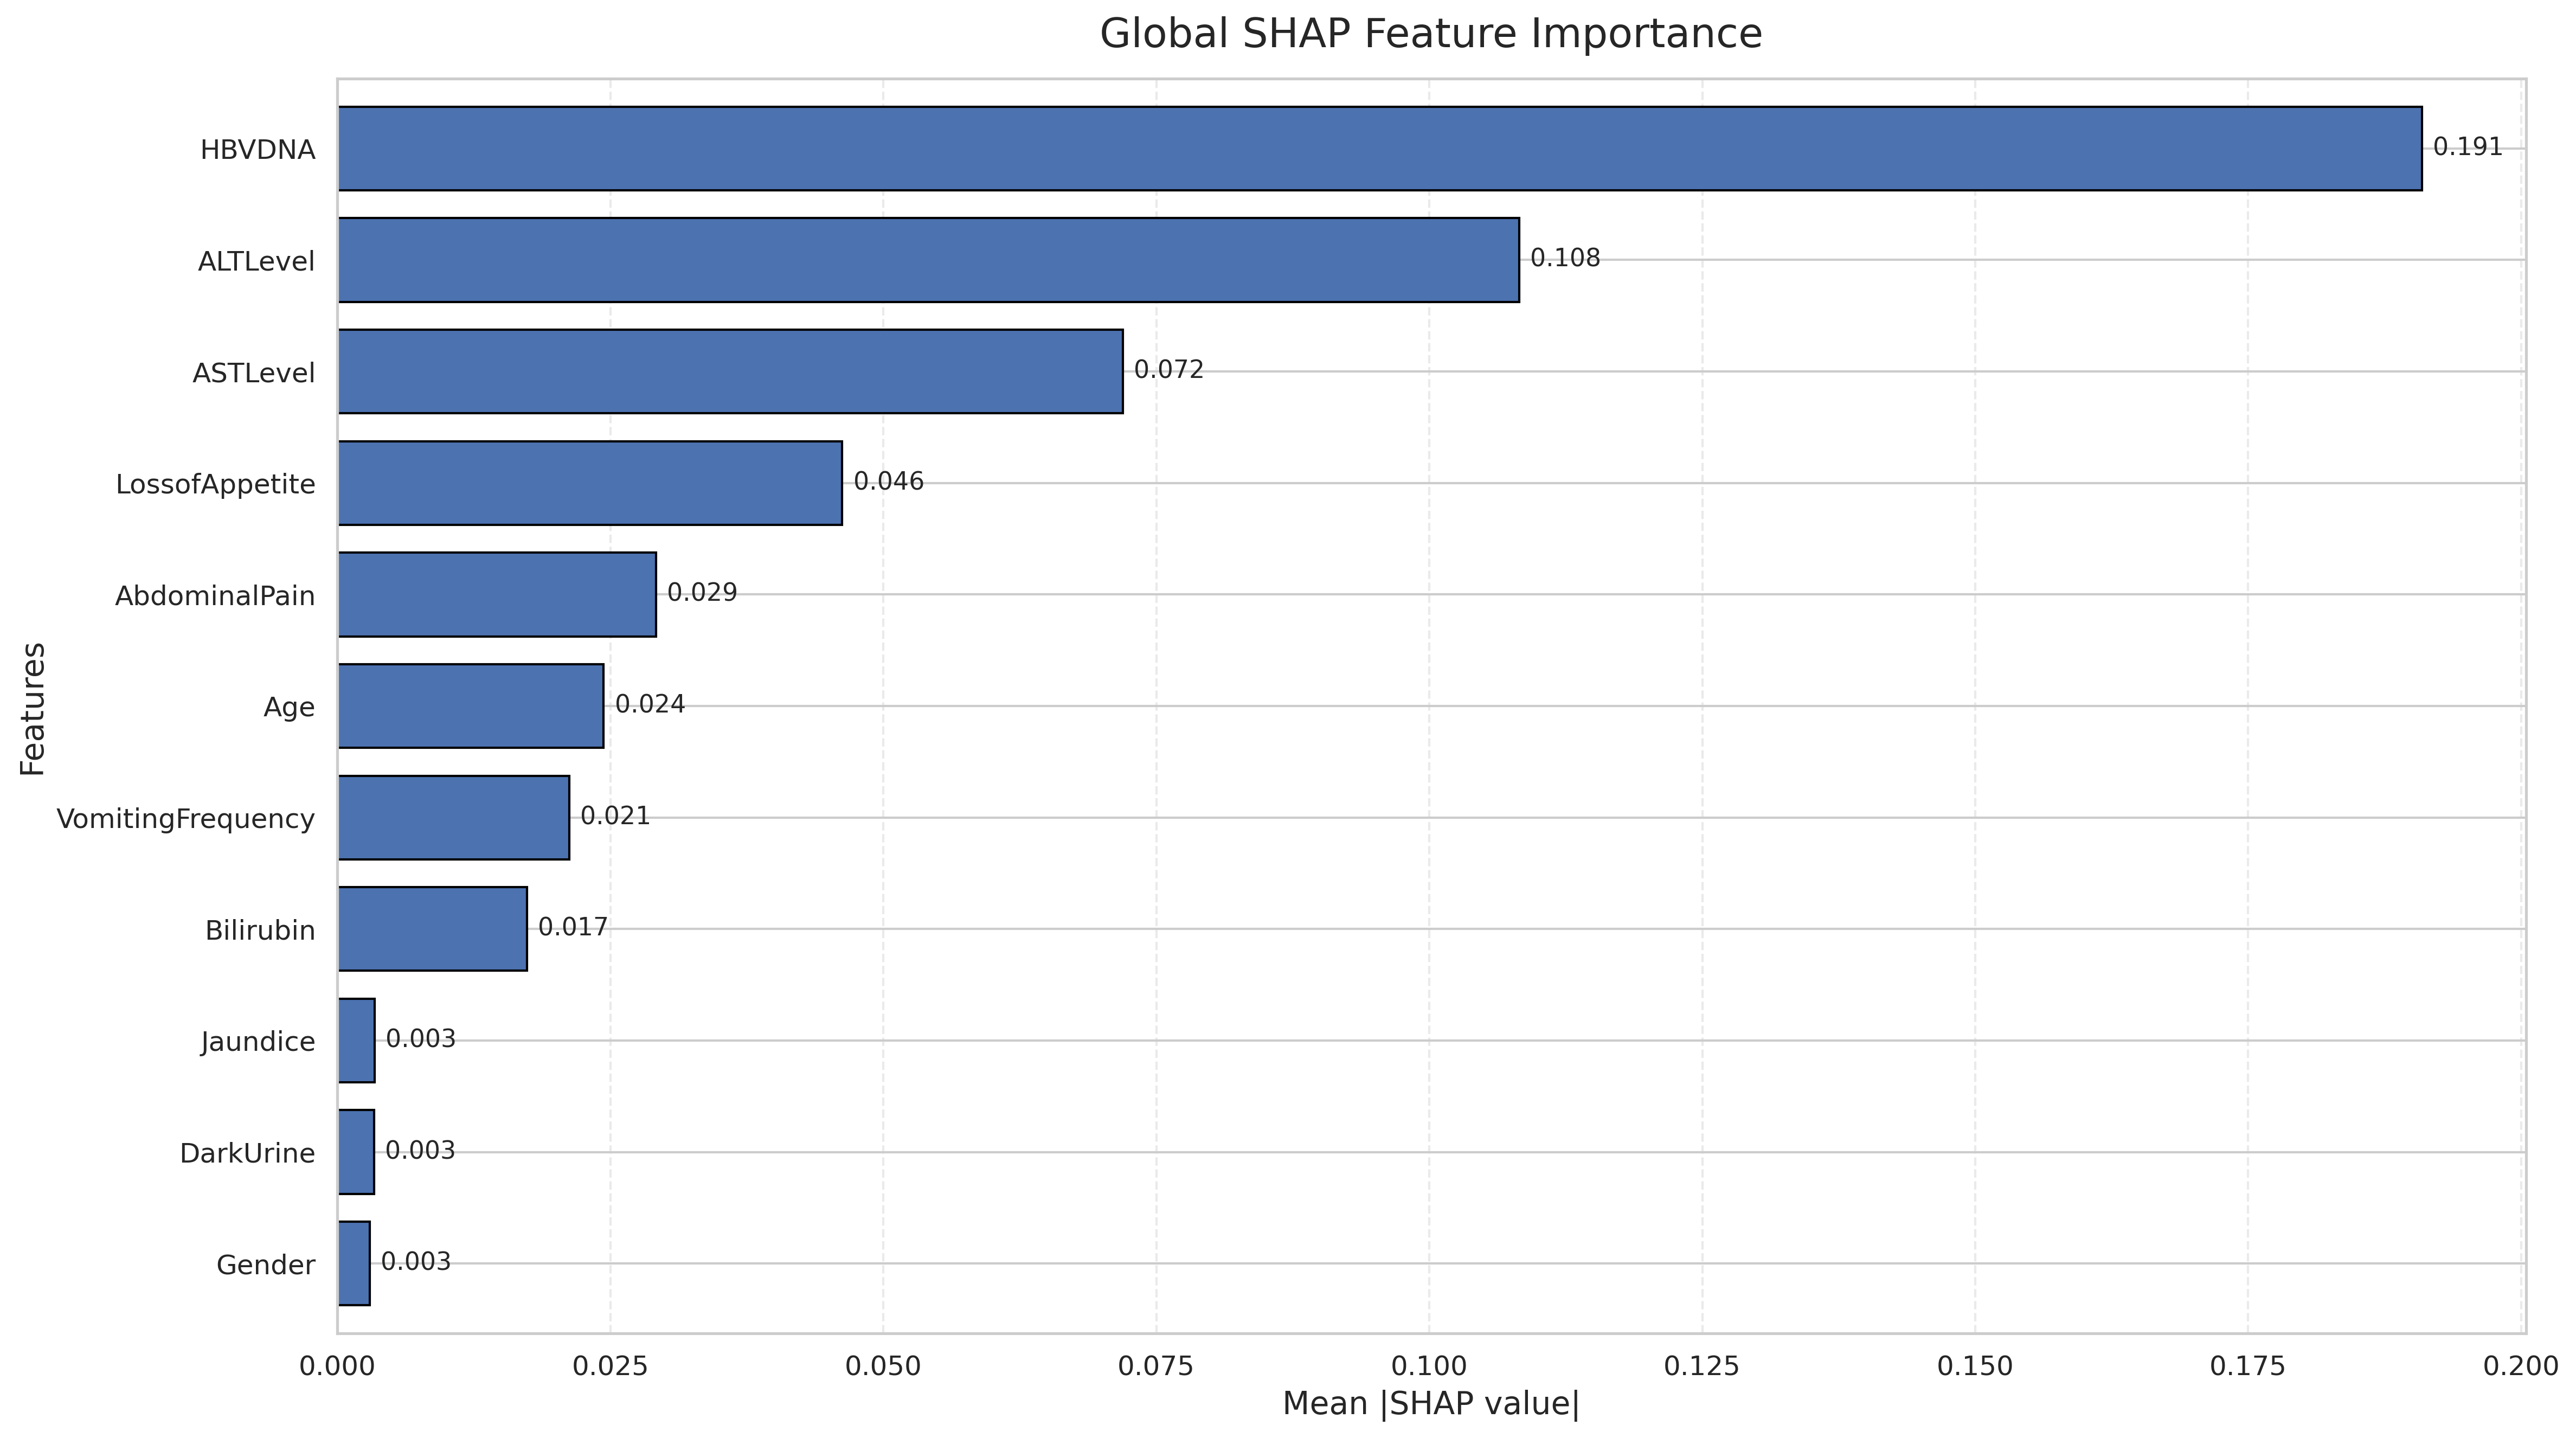

In [12]:

# SHAP GLOBAL FEATURE RANKING


rf_for_shap = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
rf_for_shap.fit(X_dev_sm, y_dev_sm)

explainer = shap.Explainer(rf_for_shap, X_dev)
shap_values = explainer(X_dev)

vals, base_vals = get_shap_matrix(shap_values)
mean_abs_shap = np.abs(vals).mean(axis=0)

shap_rank = pd.Series(mean_abs_shap, index=X_dev.columns).sort_values(ascending=False)
display(shap_rank.to_frame("MeanAbsSHAP"))


plt.figure(figsize=(16, 9), dpi=300)

ax = shap_rank.sort_values(ascending=True).plot(
    kind="barh",
    width=0.75,
    edgecolor="black"
)

plt.title("Global SHAP Feature Importance", fontsize=18, pad=14)
plt.xlabel("Mean |SHAP value|", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)


for i, v in enumerate(shap_rank.sort_values(ascending=True).values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()
plt.close()

11. choose best top k features on validation

,TopK,Val_Accuracy,Val_F1,Val_ROC_AUC
0,5,0.885714,0.888889,0.902961
1,6,0.914286,0.914286,0.930921
2,7,0.914286,0.914286,0.953947
3,8,0.885714,0.888889,0.963816
4,9,0.914286,0.914286,0.944079
5,10,0.914286,0.914286,0.950658
6,11,0.885714,0.888889,0.967105


Selected Top-K: 7
Selected features: ['HBVDNA', 'ALTLevel', 'ASTLevel', 'LossofAppetite', 'AbdominalPain', 'Age', 'VomitingFrequency']


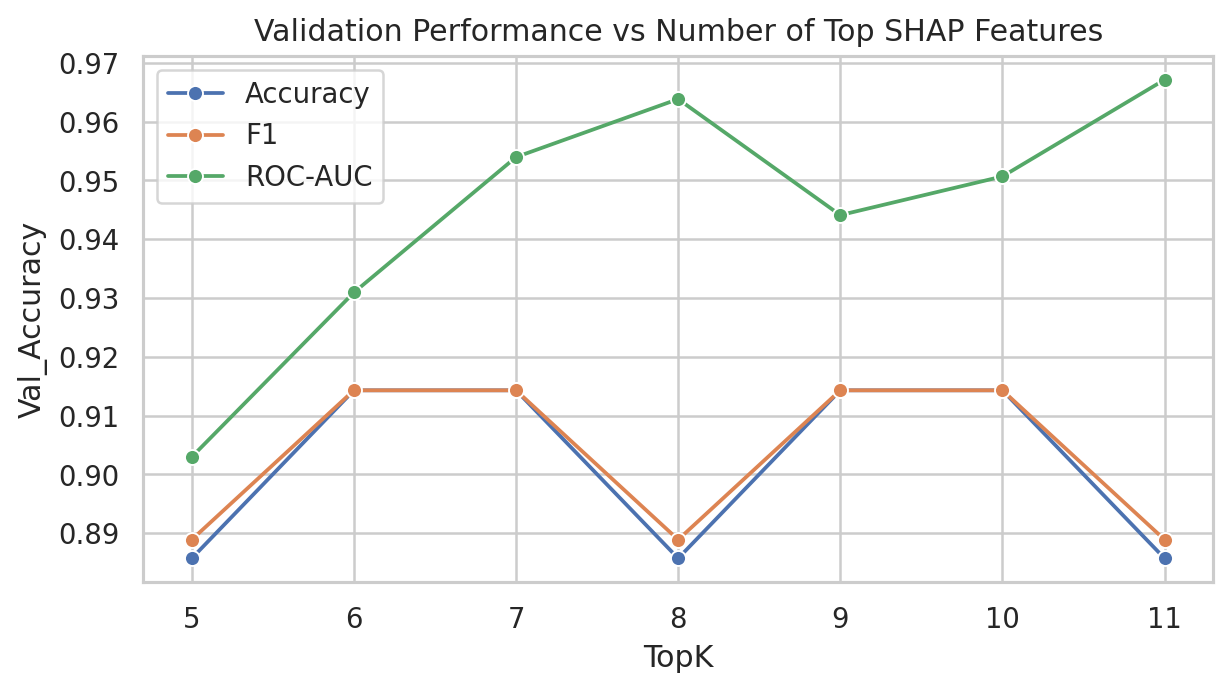

In [13]:
candidate_ks = [5, 6, 7, 8, 9, 10, 11]
feature_selection_rows = []

for k in candidate_ks:
    cols_k = shap_rank.head(k).index.tolist()

    X_dev_sm_k = pd.DataFrame(X_dev_sm, columns=X_dev.columns)[cols_k]
    X_val_k = X_val[cols_k]

    probe_rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    probe_rf.fit(X_dev_sm_k, y_dev_sm)

    val_prob = probe_rf.predict_proba(X_val_k)[:, 1]
    val_pred = (val_prob >= 0.50).astype(int)

    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)
    auc = roc_auc_score(y_val, val_prob)

    feature_selection_rows.append([k, acc, f1, auc])

feature_selection_df = pd.DataFrame(
    feature_selection_rows,
    columns=["TopK", "Val_Accuracy", "Val_F1", "Val_ROC_AUC"]
)

display(feature_selection_df)

# Choose K by highest Accuracy + F1, break ties with ROC-AUC
feature_selection_df["Objective"] = feature_selection_df["Val_Accuracy"] + feature_selection_df["Val_F1"]
best_k_row = feature_selection_df.sort_values(
    by=["Objective", "Val_ROC_AUC"],
    ascending=False
).iloc[0]

BEST_K = int(best_k_row["TopK"])
SELECTED_FEATURES = shap_rank.head(BEST_K).index.tolist()

print("Selected Top-K:", BEST_K)
print("Selected features:", SELECTED_FEATURES)

plt.figure(figsize=(7,4))
sns.lineplot(data=feature_selection_df, x="TopK", y="Val_Accuracy", marker="o", label="Accuracy")
sns.lineplot(data=feature_selection_df, x="TopK", y="Val_F1", marker="o", label="F1")
sns.lineplot(data=feature_selection_df, x="TopK", y="Val_ROC_AUC", marker="o", label="ROC-AUC")
plt.title("Validation Performance vs Number of Top SHAP Features")
save_figure(OUT_DIR / "fig_topk_selection.png")

12. hyperparameter tunning for proposed RF framework

In [14]:
X_dev_sm_df = pd.DataFrame(X_dev_sm, columns=X_dev.columns)
X_dev_sm_sel = X_dev_sm_df[SELECTED_FEATURES]
X_val_sel = X_val[SELECTED_FEATURES]

rf_search = RandomForestClassifier(random_state=RANDOM_STATE)

param_dist = {
    "n_estimators": randint(200, 1001),
    "max_depth": [None, 4, 6, 8, 10, 12, 15],
    "min_samples_split": randint(2, 12),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

search = RandomizedSearchCV(
    estimator=rf_search,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_dev_sm_sel, y_dev_sm)

best_rf = search.best_estimator_
print("Best Params:")
print(search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params:
{'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 845}
Best CV ROC-AUC: 0.98584126984127


13. validation thresold optimiztion

Best threshold:


,Threshold,Accuracy,Precision,Recall,F1,Objective
0,0.3,0.914286,1.0,0.842105,0.914286,1.828571


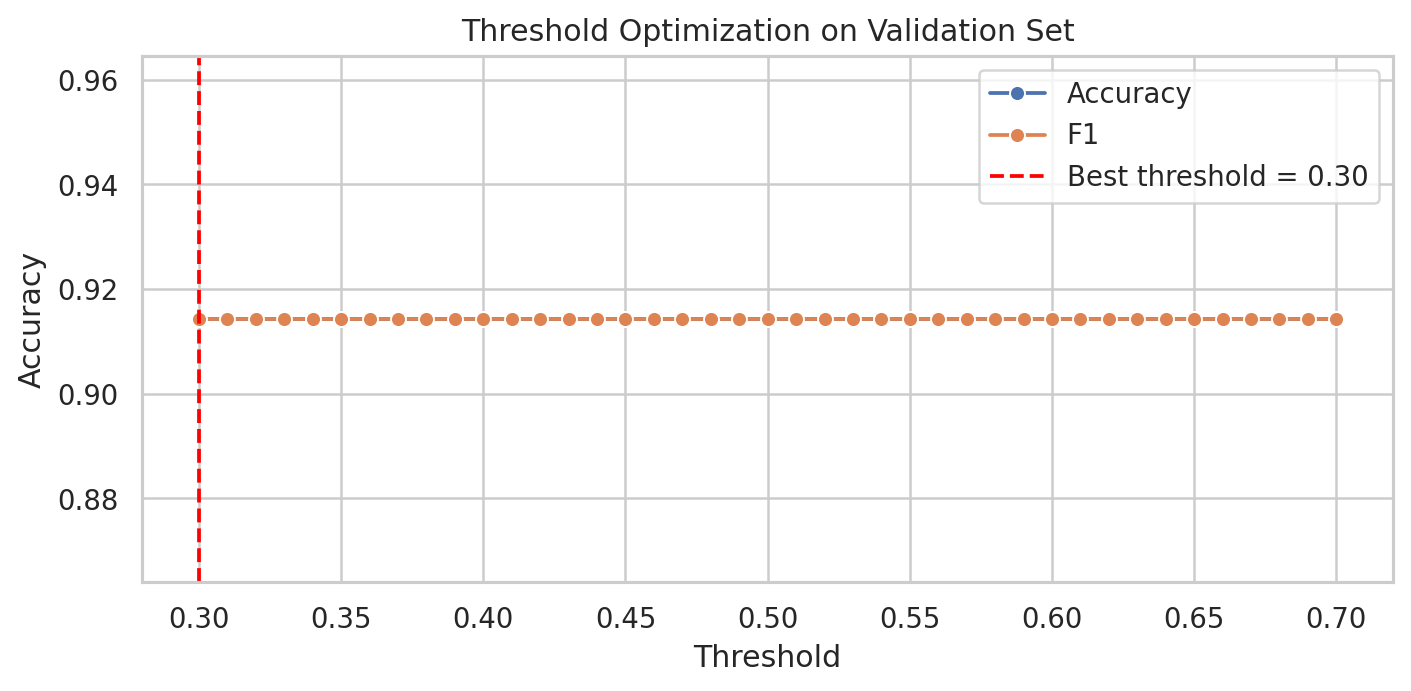

In [16]:
val_prob = best_rf.predict_proba(X_val_sel)[:, 1]

best_threshold, best_row_df, threshold_df = optimize_threshold(y_val, val_prob)

print("Best threshold:")
display(best_row_df)

plt.figure(figsize=(8,4))
sns.lineplot(data=threshold_df, x="Threshold", y="Accuracy", marker="o", label="Accuracy")
sns.lineplot(data=threshold_df, x="Threshold", y="F1", marker="o", label="F1")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Threshold Optimization on Validation Set")
plt.legend()
save_figure(OUT_DIR / "fig_threshold_optimization.png")

14. Refit final preprocessing on full outer train

In [17]:
# Refit preprocessing using full outer train only
full_train_clean, _, final_test_clean, final_boxcox_cols, final_lambdas = preprocess_fit_transform(
    train_raw, None, test_raw
)

X_train_full = full_train_clean.drop(columns=[TARGET_COL])
y_train_full = full_train_clean[TARGET_COL]

X_test_full = final_test_clean.drop(columns=[TARGET_COL])
y_test = final_test_clean[TARGET_COL]

print("Final train shape:", X_train_full.shape)
print("Final test shape:", X_test_full.shape)
print("Final Box-Cox columns:", final_boxcox_cols)

Final train shape: (172, 11)
Final test shape: (44, 11)
Final Box-Cox columns: ['HBVDNA', 'ALTLevel', 'ASTLevel', 'Bilirubin']


15. final smote on full outer

In [18]:
smote_final = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_full_sm, y_train_full_sm = smote_final.fit_resample(X_train_full, y_train_full)

X_train_full_sm = pd.DataFrame(X_train_full_sm, columns=X_train_full.columns)
X_train_full_sel = X_train_full_sm[SELECTED_FEATURES]
X_test_sel = X_test_full[SELECTED_FEATURES]

print("Before SMOTE:")
print(y_train_full.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_full_sm).value_counts())

Before SMOTE:
Status
1    92
0    80
Name: count, dtype: int64

After SMOTE:
Status
1    92
0    92
Name: count, dtype: int64


16. Train final proposed model HepatoXAI-RF

In [19]:
final_model = RandomForestClassifier(**search.best_params_, random_state=RANDOM_STATE)
final_model.fit(X_train_full_sel, y_train_full_sm)

test_prob = final_model.predict_proba(X_test_sel)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

final_metrics = eval_metrics(y_test, test_pred, test_prob)
final_metrics["Threshold"] = best_threshold

print("Final Proposed Model: HepatoXAI-RF")
print(final_metrics)
print("\nClassification Report:")
print(classification_report(y_test, test_pred, digits=4))

Final Proposed Model: HepatoXAI-RF
{'Accuracy': 0.9545454545454546, 'Precision': 0.9583333333333334, 'Recall': 0.9583333333333334, 'F1': 0.9583333333333334, 'ROC_AUC': np.float64(0.9875), 'Brier': np.float64(0.04421040177230079), 'Threshold': np.float64(0.3)}

Classification Report:
              precision    recall  f1-score   support

           0     0.9500    0.9500    0.9500        20
           1     0.9583    0.9583    0.9583        24

    accuracy                         0.9545        44
   macro avg     0.9542    0.9542    0.9542        44
weighted avg     0.9545    0.9545    0.9545        44



17. confussion matrix for proposed model

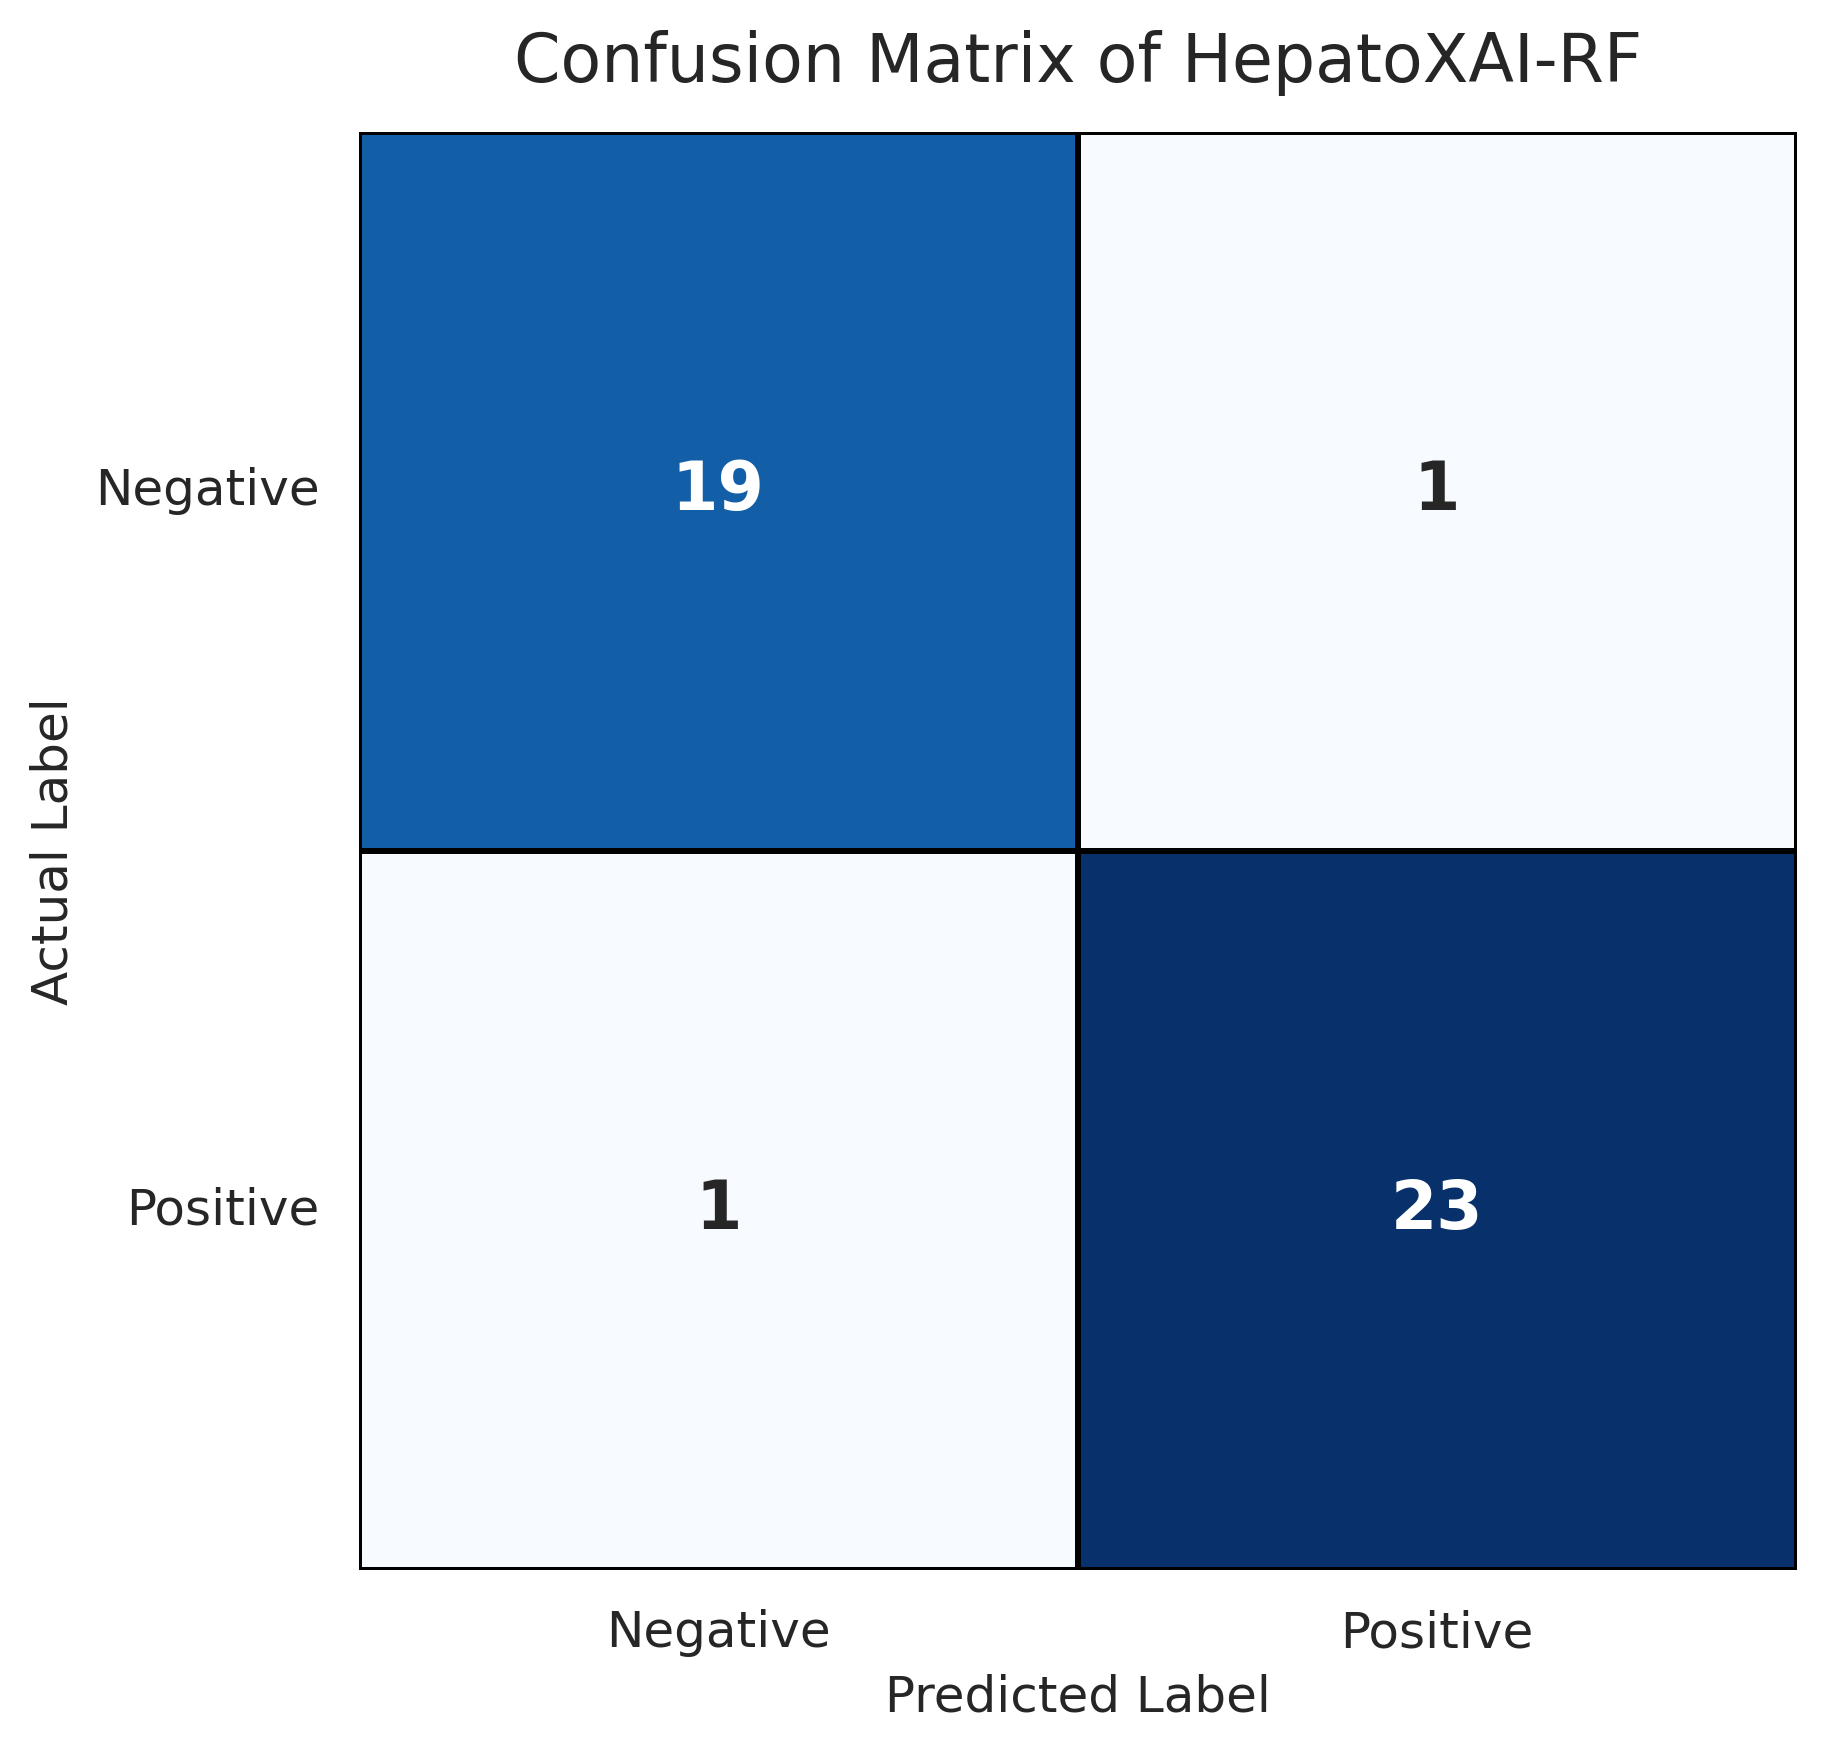

In [20]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="black",
    square=True,
    annot_kws={"size": 16, "weight": "bold"},
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("Confusion Matrix of HepatoXAI-RF", fontsize=16, pad=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()
plt.close()

18. Calibration Curve

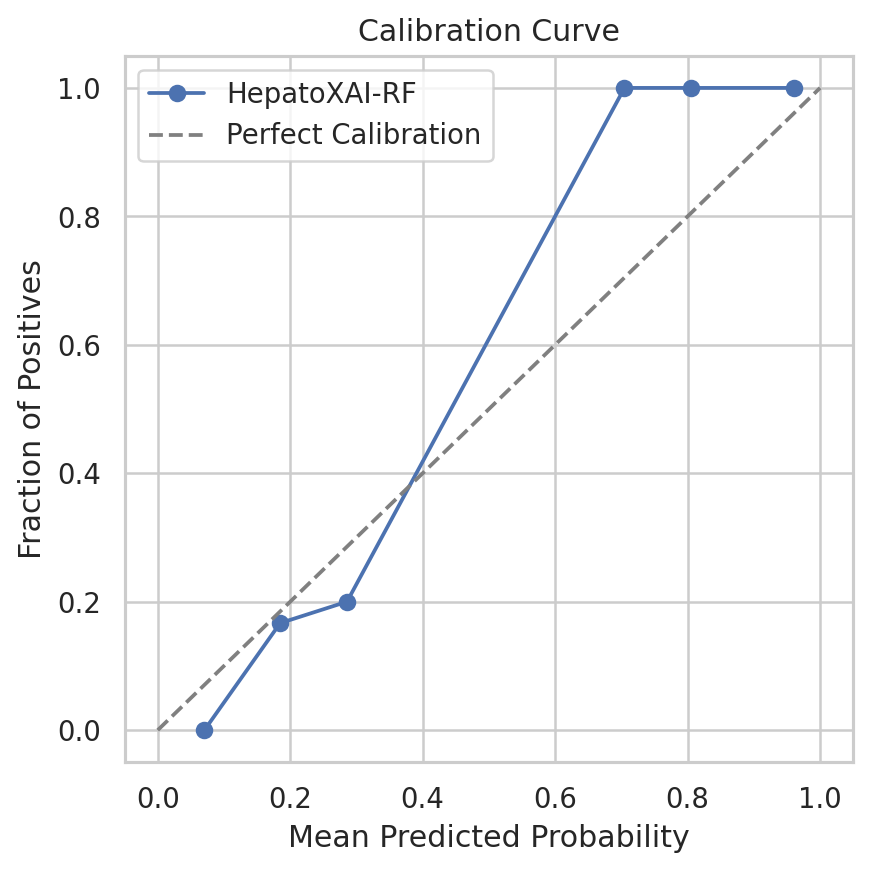

In [21]:
frac_pos, mean_pred = calibration_curve(y_test, test_prob, n_bins=8)

plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, marker="o", label="HepatoXAI-RF")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
save_figure(OUT_DIR / "fig_calibration_curve.png")

19. Multiseed robustness for proposed model

In [22]:
seed_results = []

for seed in [11, 21, 33, 42, 66, 77, 88, 99]:
    # Outer split
    train_s, test_s = train_test_split(
        model_df,
        test_size=0.20,
        stratify=model_df[TARGET_COL],
        random_state=seed
    )

    # Inner split for selecting threshold only
    dev_s, val_s = train_test_split(
        train_s,
        test_size=0.20,
        stratify=train_s[TARGET_COL],
        random_state=seed
    )

    dev_s_clean, val_s_clean, _, _, _ = preprocess_fit_transform(dev_s, val_s, None)
    X_dev_s = dev_s_clean.drop(columns=[TARGET_COL])
    y_dev_s = dev_s_clean[TARGET_COL]
    X_val_s = val_s_clean.drop(columns=[TARGET_COL])
    y_val_s = val_s_clean[TARGET_COL]

    sm = SMOTE(random_state=seed, k_neighbors=5)
    X_dev_s_sm, y_dev_s_sm = sm.fit_resample(X_dev_s, y_dev_s)
    X_dev_s_sm = pd.DataFrame(X_dev_s_sm, columns=X_dev_s.columns)

    # Use same selected features and best params from development notebook
    X_dev_s_sm_sel = X_dev_s_sm[SELECTED_FEATURES]
    X_val_s_sel = X_val_s[SELECTED_FEATURES]

    model_s = RandomForestClassifier(**search.best_params_, random_state=seed)
    model_s.fit(X_dev_s_sm_sel, y_dev_s_sm)

    val_prob_s = model_s.predict_proba(X_val_s_sel)[:, 1]
    th_s, _, _ = optimize_threshold(y_val_s, val_prob_s)

    # Fit on full train_s and test on untouched test_s
    train_s_clean, _, test_s_clean, _, _ = preprocess_fit_transform(train_s, None, test_s)
    X_train_s = train_s_clean.drop(columns=[TARGET_COL])
    y_train_s = train_s_clean[TARGET_COL]
    X_test_s = test_s_clean.drop(columns=[TARGET_COL])
    y_test_s = test_s_clean[TARGET_COL]

    X_train_s_sm, y_train_s_sm = sm.fit_resample(X_train_s, y_train_s)
    X_train_s_sm = pd.DataFrame(X_train_s_sm, columns=X_train_s.columns)

    X_train_s_sel = X_train_s_sm[SELECTED_FEATURES]
    X_test_s_sel = X_test_s[SELECTED_FEATURES]

    model_s.fit(X_train_s_sel, y_train_s_sm)

    prob_s = model_s.predict_proba(X_test_s_sel)[:, 1]
    pred_s = (prob_s >= th_s).astype(int)

    row = {"Seed": seed}
    row.update(eval_metrics(y_test_s, pred_s, prob_s))
    seed_results.append(row)

seed_df = pd.DataFrame(seed_results)
display(seed_df)

summary_df = pd.DataFrame([
    {
        "Metric": metric,
        "Mean": seed_df[metric].mean(),
        "Std": seed_df[metric].std(ddof=1)
    }
    for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Brier"]
])

display(summary_df)

seed_df.to_csv(OUT_DIR / "proposed_multiseed_results.csv", index=False)
summary_df.to_csv(OUT_DIR / "proposed_multiseed_summary.csv", index=False)

,Seed,Accuracy,Precision,Recall,F1,ROC_AUC,Brier
0,11,0.886364,0.952381,0.833333,0.888889,0.970833,0.069454
1,21,0.931818,1.000000,0.875000,0.933333,0.985417,0.053296
2,33,0.931818,1.000000,0.875000,0.933333,0.970833,0.062283
3,42,0.954545,0.958333,0.958333,0.958333,0.987500,0.044210
4,66,0.886364,1.000000,0.791667,0.883721,0.956250,0.090553
5,77,0.977273,1.000000,0.958333,0.978723,0.991667,0.037600
6,88,0.977273,1.000000,0.958333,0.978723,0.995833,0.027468
7,99,0.886364,0.880000,0.916667,0.897959,0.964583,0.051808


,Metric,Mean,Std
0,Accuracy,0.928977,0.039247
1,Precision,0.973839,0.042976
2,Recall,0.895833,0.062994
3,F1,0.931627,0.038564
4,ROC_AUC,0.977865,0.014171
5,Brier,0.054584,0.019693


20. SHAP explanability for proposed model

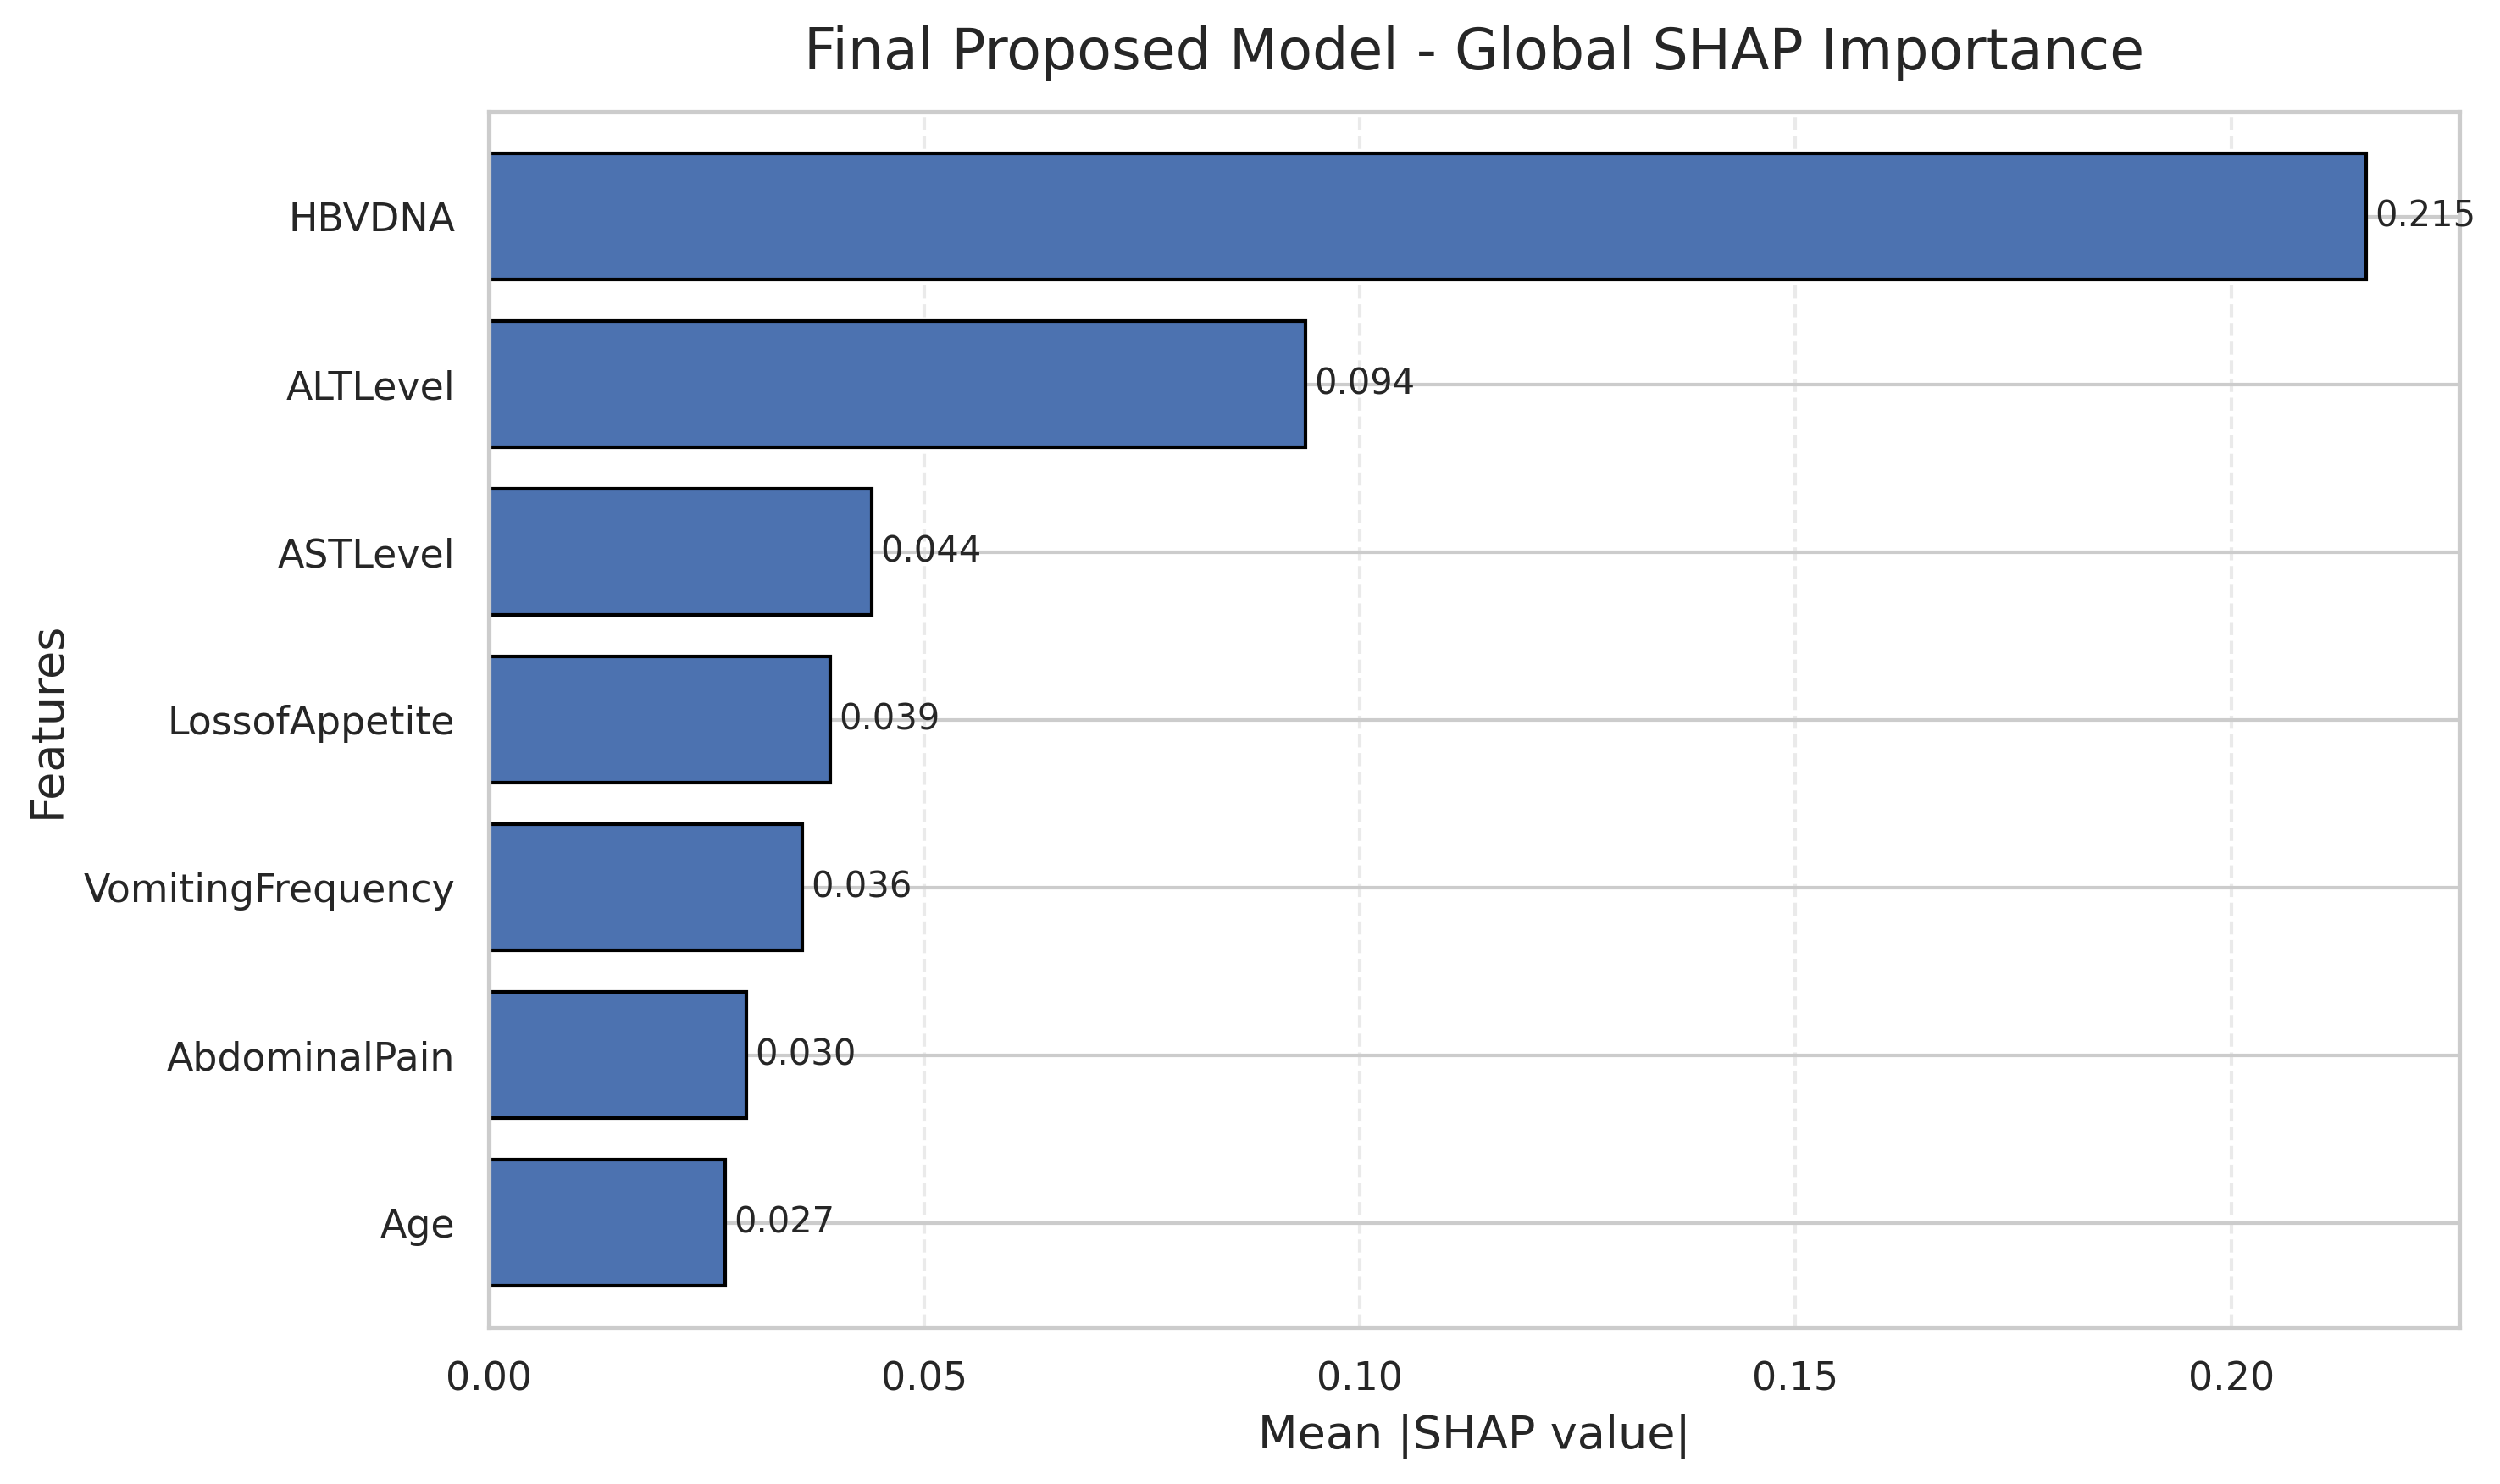

In [23]:
final_explainer = shap.Explainer(final_model, X_train_full_sel)
final_shap_values = final_explainer(X_test_sel)

final_vals, final_base = get_shap_matrix(final_shap_values)

# Global bar plot
mean_abs_final = np.abs(final_vals).mean(axis=0)
final_shap_rank = pd.Series(mean_abs_final, index=X_test_sel.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

final_shap_rank.sort_values(ascending=True).plot(
    kind="barh",
    ax=ax,
    width=0.75,
    edgecolor="black"
)

ax.set_title("Final Proposed Model - Global SHAP Importance", fontsize=16, pad=12)
ax.set_xlabel("Mean |SHAP value|", fontsize=13)
ax.set_ylabel("Features", fontsize=13)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)

for i, v in enumerate(final_shap_rank.sort_values(ascending=True).values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()
plt.close()

21. SHAP Waterfall plot for positive and negative cases

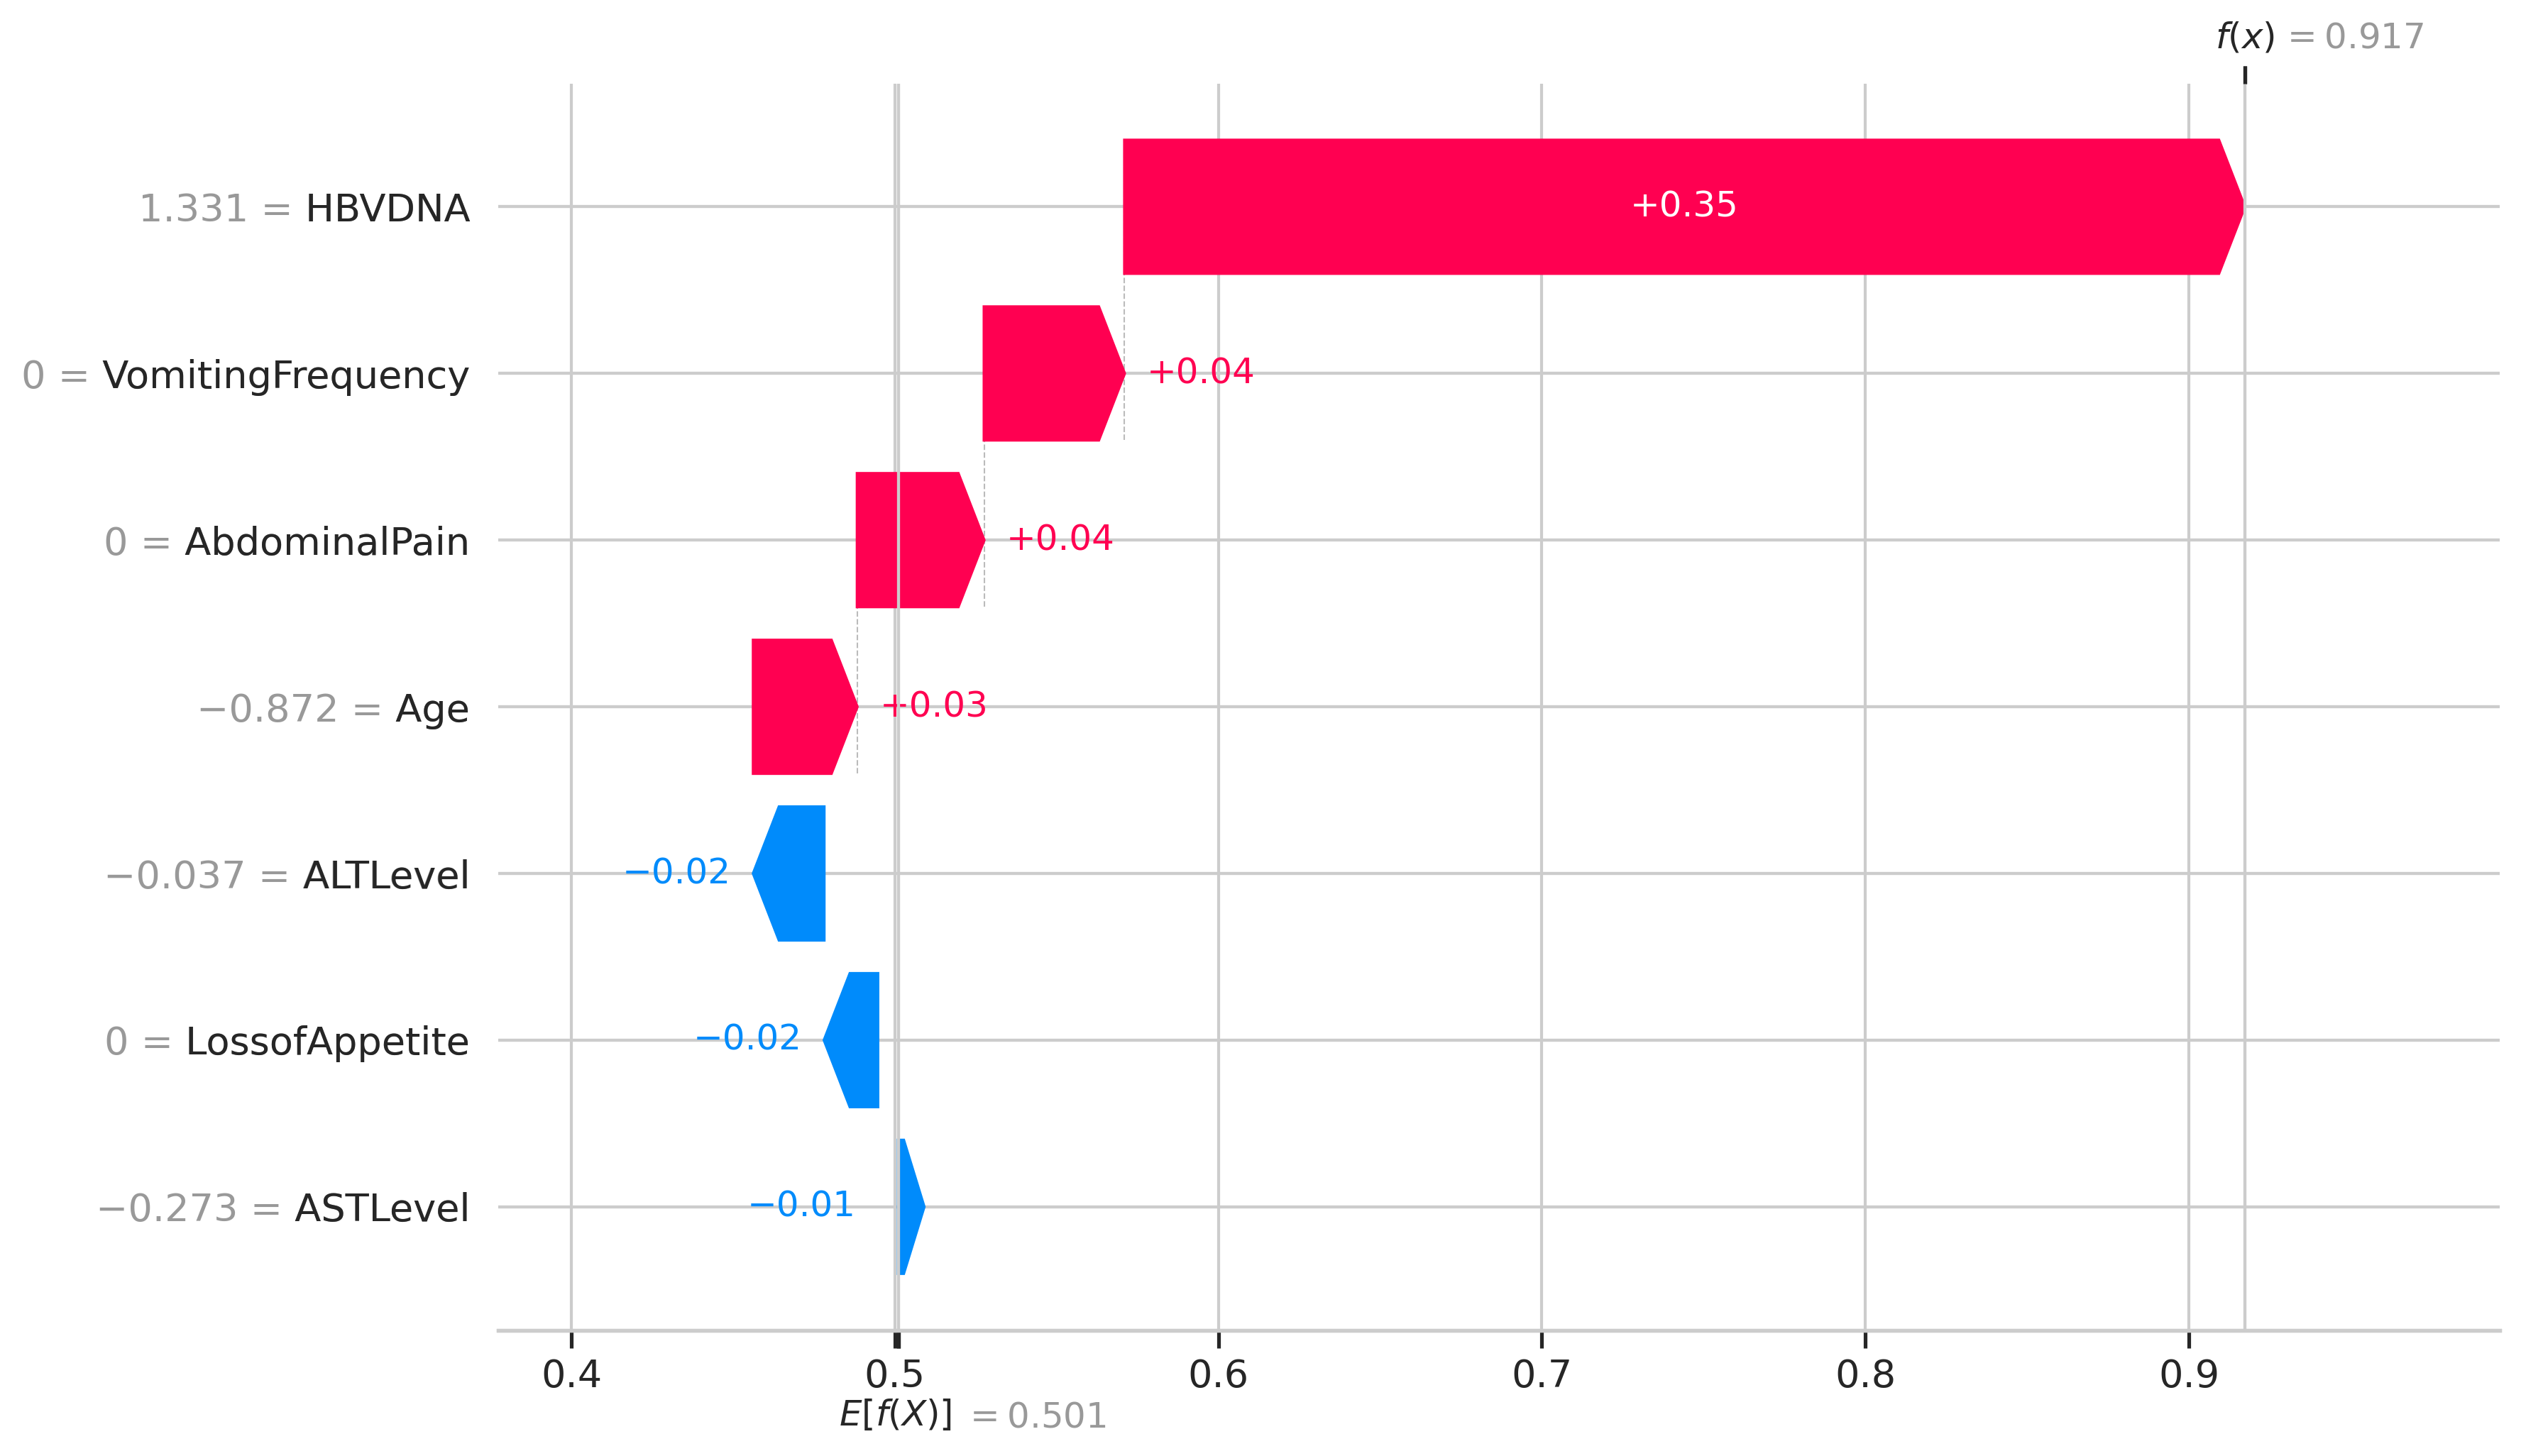

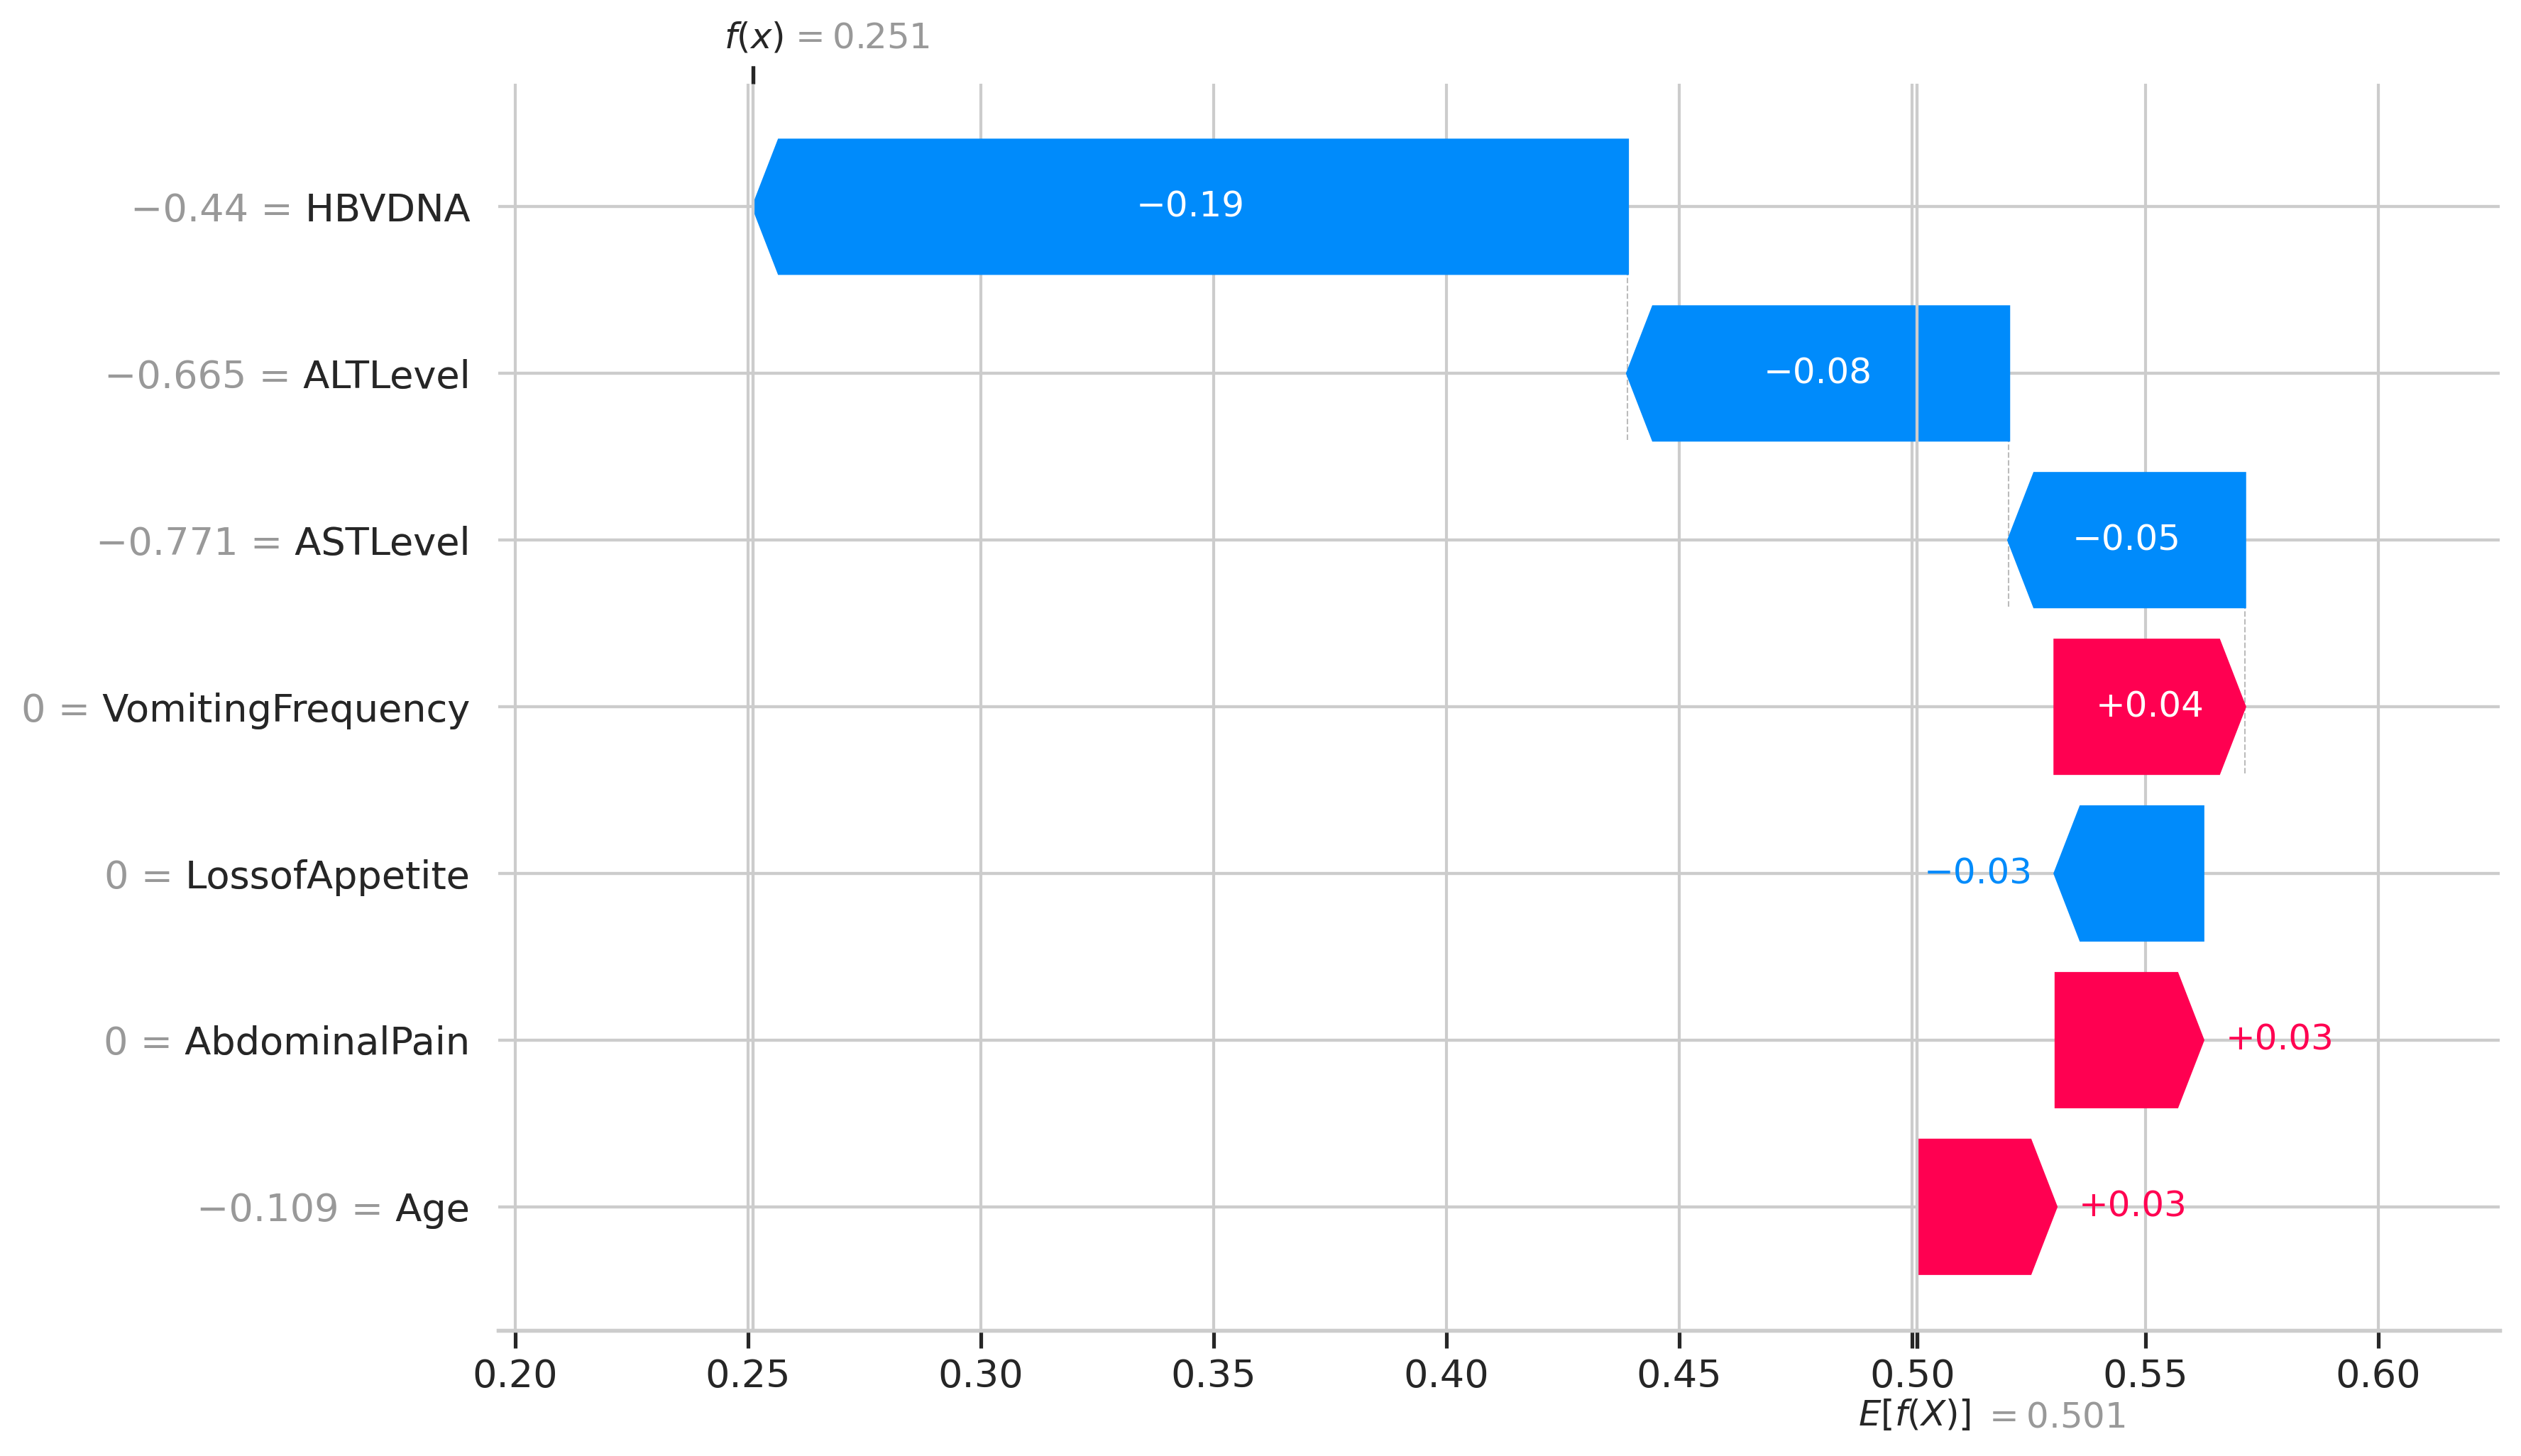

In [24]:
# Convert to positive-class explanation if needed
if final_shap_values.values.ndim == 3:
    shap_pos = shap.Explanation(
        values=final_shap_values.values[:, :, 1],
        base_values=final_shap_values.base_values[:, 1],
        data=final_shap_values.data,
        feature_names=final_shap_values.feature_names
    )
else:
    shap_pos = final_shap_values

pos_idx = int(np.where(y_test.values == 1)[0][0])
neg_idx = int(np.where(y_test.values == 0)[0][0])

# Positive case waterfall plot
plt.figure(figsize=(12, 7), dpi=300)
shap.plots.waterfall(shap_pos[pos_idx], show=False)
plt.gcf().set_size_inches(12, 7)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()
plt.close()

# Negative case waterfall plot
plt.figure(figsize=(12, 7), dpi=300)
shap.plots.waterfall(shap_pos[neg_idx], show=False)
plt.gcf().set_size_inches(12, 7)
plt.gcf().set_dpi(300)
plt.tight_layout()
plt.show()
plt.close()

22. SHAP Force pLot

In [25]:
from IPython.display import display, HTML
import shap

shap.initjs()

# Convert to positive-class explanation if needed
if final_shap_values.values.ndim == 3:
    shap_pos = shap.Explanation(
        values=final_shap_values.values[:, :, 1],
        base_values=final_shap_values.base_values[:, 1],
        data=final_shap_values.data,
        feature_names=final_shap_values.feature_names
    )
else:
    shap_pos = final_shap_values

# First positive and negative test instances
pos_idx = int(np.where(y_test.values == 1)[0][0])
neg_idx = int(np.where(y_test.values == 0)[0][0])


# Force plot for HBV-positive case

print("SHAP Force Plot for HBV-Positive Case")
display(HTML(shap.plots.force(
    shap_pos.base_values[pos_idx],
    shap_pos.values[pos_idx],
    shap_pos.data[pos_idx],
    feature_names=shap_pos.feature_names,
    matplotlib=False
).html()))


# Force plot for HBV-negative case

print("SHAP Force Plot for HBV-Negative Case")
display(HTML(shap.plots.force(
    shap_pos.base_values[neg_idx],
    shap_pos.values[neg_idx],
    shap_pos.data[neg_idx],
    feature_names=shap_pos.feature_names,
    matplotlib=False
).html()))

SHAP Force Plot for HBV-Positive Case


SHAP Force Plot for HBV-Negative Case


23. Multiseed baseline comparision

In [26]:
baseline_models_multi = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (Linear)": SVC(kernel="linear", probability=True),
    "Default RF": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB()
}

multi_seed_results = []

for model_name, base_model in baseline_models_multi.items():

    for seed in [11, 21, 33, 42, 66, 77, 88, 99]:

        # Outer split
        train_s, test_s = train_test_split(
            model_df,
            test_size=0.20,
            stratify=model_df[TARGET_COL],
            random_state=seed
        )

        # Preprocess
        train_clean, _, test_clean, _, _ = preprocess_fit_transform(train_s, None, test_s)

        X_train = train_clean.drop(columns=[TARGET_COL])
        y_train = train_clean[TARGET_COL]

        X_test = test_clean.drop(columns=[TARGET_COL])
        y_test_s = test_clean[TARGET_COL]

        # SMOTE
        sm = SMOTE(random_state=seed)
        X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

        X_train_sm = pd.DataFrame(X_train_sm, columns=X_train.columns)

        # Use SAME selected features
        X_train_sel = X_train_sm[SELECTED_FEATURES]
        X_test_sel = X_test[SELECTED_FEATURES]

        # Train
        model = base_model
        model.fit(X_train_sel, y_train_sm)

        prob = model.predict_proba(X_test_sel)[:, 1]
        pred = (prob >= 0.5).astype(int)

        row = {
            "Model": model_name,
            "Seed": seed
        }
        row.update(eval_metrics(y_test_s, pred, prob))
        multi_seed_results.append(row)

multi_seed_df = pd.DataFrame(multi_seed_results)

summary_multi = multi_seed_df.groupby("Model").agg(
    ["mean", "std"]
)

display(summary_multi)

Seed             Accuracy           Precision  \
                       mean        std      mean       std      mean   
Model                                                                  
Decision Tree        54.625  32.456289  0.900568  0.065350  0.911453   
Default RF           54.625  32.456289  0.923295  0.031997  0.966082   
Gradient Boosting    54.625  32.456289  0.923295  0.040177  0.966453   
KNN                  54.625  32.456289  0.892045  0.039831  0.935321   
Logistic Regression  54.625  32.456289  0.926136  0.037933  0.983178   
Naive Bayes          54.625  32.456289  0.818182  0.050088  1.000000   
SVM (Linear)         54.625  32.456289  0.914773  0.048212  0.974048   

                                 Recall                  F1            \
                          std      mean       std      mean       std   
Model                                                                   
Decision Tree        0.061669  0.906250  0.069544  0.908308  0.061390   
Default RF           0.021044  0.890625  0.049489  0.926286  0.032444   
Gradient Boosting    0.030608  0.890625  0.062748  0.925980  0.041595   
KNN                  0.053050  0.864583  0.053406  0.897171  0.037660   
Logistic Regression  0.032875  0.880208  0.056508  0.927951  0.037878   
Naive Bayes          0.000000  0.666667  0.091829  0.796705  0.068464   
SVM (Linear)         0.056669  0.869792  0.064694  0.917171  0.046627   

                      ROC_AUC               Brier            
                         mean       std      mean       std  
Model                                                        
Decision Tree        0.900000  0.065465  0.099432  0.065350  
Default RF           0.968099  0.017179  0.056157  0.018158  
Gradient Boosting    0.960417  0.027026  0.062444  0.029822  
KNN                  0.953516  0.020563  0.074886  0.021644  
Logistic Regression  0.951042  0.031220  0.068475  0.023717  
Naive Bayes          0.952865  0.011623  0.170879  0.051952  
SVM (Linear)         0.953906  0.031486  0.066918  0.025304